In [2]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

# ============================================================
# CORE NUMERICAL & DATA HANDLING
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STATISTICAL TESTING
# ============================================================
from scipy import stats

# ============================================================
# SKLEARN: MODEL SELECTION & VALIDATION
# ============================================================
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)

# ============================================================
# SKLEARN: MODELS
# ============================================================
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# SKLEARN: METRICS & FEATURE IMPORTANCE
# ============================================================
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    mutual_info_score,
)
from sklearn.inspection import permutation_importance

# ============================================================
# GRADIENT BOOSTING
# ============================================================
import xgboost as xgb

# ============================================================
# RULE / ILP / STRUCTURAL UTILITIES
# ============================================================
import itertools
from collections import defaultdict
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set

# ============================================================
# WARNINGS CONTROL
# ============================================================
import warnings
warnings.filterwarnings("ignore")


In [3]:
# ============================================================
# CELL 2: LOAD & INSPECT DATA
# ============================================================

# Load dataset
path = "/content/sample_data/bank-full.csv"
df = pd.read_csv(path, sep=";")

print(f"Shape: {df.shape}")
df.head()


Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# ============================================================
# CELL 4: EXAMINE CATAGORICAL COLUMNS
# ============================================================
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("📌 CATEGORICAL COLUMNS\n" + "-"*60)
categorical_cols

for col in categorical_cols:
    print(f"\n🔎 Column: {col}")
    print("-" * 40)

    values = (
        df[col]
        .astype(str)
        .value_counts(dropna=False)
        .sort_index()
    )

    print(values)


📌 CATEGORICAL COLUMNS
------------------------------------------------------------

🔎 Column: job
----------------------------------------
job
admin.           5171
blue-collar      9732
entrepreneur     1487
housemaid        1240
management       9458
retired          2264
self-employed    1579
services         4154
student           938
technician       7597
unemployed       1303
unknown           288
Name: count, dtype: int64

🔎 Column: marital
----------------------------------------
marital
divorced     5207
married     27214
single      12790
Name: count, dtype: int64

🔎 Column: education
----------------------------------------
education
primary       6851
secondary    23202
tertiary     13301
unknown       1857
Name: count, dtype: int64

🔎 Column: default
----------------------------------------
default
no     44396
yes      815
Name: count, dtype: int64

🔎 Column: housing
----------------------------------------
housing
no     20081
yes    25130
Name: count, dtype: int64

🔎 Co

In [5]:
# ============================================================
# CELL 5: PREPROCESSING + FEATURE ENGINEERING + TUNING
# ============================================================

print("\n" + "="*80)
print("🔧 CLEAN PREPROCESSING FROM SCRATCH (NUMERIC-ONLY)")
print("="*80)

print(f"\nOriginal data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# --------------------------------------------------
# 1. CREATE CLEAN df_proc FRAME
# --------------------------------------------------
print("\n" + "="*40)
print("1. CREATING CLEAN df_proc")
print("="*40)

df_proc = df.copy()

print(f"\nInitial shape: {df_proc.shape}")
print(f"Columns: {list(df_proc.columns)}")

# --------------------------------------------------
# 1.1 Target encoding (STRICT)
# --------------------------------------------------
print(f"\n🔍 Target column 'y' before conversion:")
print(df_proc['y'].value_counts())

df_proc['y'] = df_proc['y'].map({'yes': 1, 'no': 0})
assert df_proc['y'].notna().all(), "❌ Unexpected values in target y"
df_proc['y'] = df_proc['y'].astype('int8')

print(f"\n✅ Target 'y' converted:")
print(df_proc['y'].value_counts())

# --------------------------------------------------
# 1.2 Binary categorical encoding
# --------------------------------------------------
binary_cols = ['default', 'housing', 'loan']
binary_map = {'no': 0, 'yes': 1}

print(f"\n🔍 Binary columns before conversion:")
for col in binary_cols:
    print(f"{col}:\n{df_proc[col].value_counts()}")

for col in binary_cols:
    df_proc[col] = df_proc[col].map(binary_map)
    assert df_proc[col].notna().all(), f"❌ Unexpected values in {col}"
    df_proc[col] = df_proc[col].astype('int8')

print(f"\n✅ Binary columns converted:")
for col in binary_cols:
    print(f"{col}: {df_proc[col].unique()}")

# --------------------------------------------------
# 1.3 Month → ordinal
# --------------------------------------------------
print(f"\n🔍 Month column before conversion:")
print(df_proc['month'].value_counts().sort_index())

month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

df_proc['month'] = df_proc['month'].map(month_map)
assert df_proc['month'].notna().all(), "❌ Unexpected month values"

df_proc['month'] = df_proc['month'].astype('int8')

print(f"\n✅ Month converted to ordinal")

# --------------------------------------------------
# 1.4 POUTCOME - EXPLICIT MAPPING
# --------------------------------------------------
print(f"\n🔍 poutcome column before conversion:")
print(df_proc['poutcome'].value_counts())

poutcome_map = {
    'unknown': 0,
    'failure': 1,
    'other': 2,
    'success': 3
}

df_proc['poutcome'] = df_proc['poutcome'].map(poutcome_map)
assert df_proc['poutcome'].notna().all(), "❌ Unexpected poutcome values"
df_proc['poutcome'] = df_proc['poutcome'].astype('int8')

print(f"\n✅ poutcome converted:")
print(df_proc['poutcome'].value_counts())

# --------------------------------------------------
# 1.5 CONTACT - ORDINAL MAPPING
# --------------------------------------------------
print(f"\n🔍 contact column before conversion:")
print(df_proc['contact'].value_counts())

contact_map = {
    'cellular': 0,
    'telephone': 1,
    'unknown': 2
}

df_proc['contact'] = df_proc['contact'].map(contact_map)
assert df_proc['contact'].notna().all(), "❌ Unexpected contact values"
df_proc['contact'] = df_proc['contact'].astype('int8')

print(f"\n✅ contact converted to ordinal:")
print(df_proc['contact'].value_counts().sort_index())

# --------------------------------------------------
# 1.6 Ordinal / Label encoding REMAINING categoricals
# --------------------------------------------------
categorical_cols = df_proc.select_dtypes(include=['object']).columns.tolist()

print(f"\n🔍 Ordinal-encoding remaining categoricals:")
print(categorical_cols)

for col in categorical_cols:
    df_proc[col] = df_proc[col].astype('category').cat.codes
    df_proc[col] = df_proc[col].astype('int16')

# --------------------------------------------------
# 1.7 HARD TYPE GUARANTEE
# --------------------------------------------------
non_numeric = df_proc.select_dtypes(exclude=['number']).columns.tolist()
assert len(non_numeric) == 0, f"❌ NON-NUMERIC COLUMNS REMAIN: {non_numeric}"

print("\n✅ ALL COLUMNS ARE NUMERIC")

# --------------------------------------------------
# 1.8 Sanity checks
# --------------------------------------------------
print(f"\n📊 Data types in df_proc:")
for dtype in df_proc.dtypes.unique():
    cols = df_proc.columns[df_proc.dtypes == dtype].tolist()
    print(f"{dtype}: {cols}")

print(f"\n🔍 Checking for null values:")
assert df_proc.isnull().sum().sum() == 0, "❌ Nulls detected"
print("✅ No null values")

print(f"\n🔍 Checking for duplicates:")
dup_count = df_proc.duplicated().sum()
print(f"Exact duplicate rows: {dup_count} ({dup_count/len(df_proc)*100:.2f}%)")

print(f"\n✅ df_proc created successfully!")
print(f"Shape: {df_proc.shape}")
print(f"Memory usage: {df_proc.memory_usage().sum() / 1024**2:.2f} MB")




🔧 CLEAN PREPROCESSING FROM SCRATCH (NUMERIC-ONLY)

Original data shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

1. CREATING CLEAN df_proc

Initial shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

🔍 Target column 'y' before conversion:
y
no     39922
yes     5289
Name: count, dtype: int64

✅ Target 'y' converted:
y
0    39922
1     5289
Name: count, dtype: int64

🔍 Binary columns before conversion:
default:
default
no     44396
yes      815
Name: count, dtype: int64
housing:
housing
yes    25130
no     20081
Name: count, dtype: int64
loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

✅ Binary columns converted:
default: [0 1]
housing: [1 0]
loan: [0 1]

🔍 Month column before con

In [6]:
# ============================================================
# CELL 6: GLOBAL TRAIN / TEST SPLIT (AUTHORITATIVE)
# PURPOSE:
# - Single, fixed split shared by ALL models
# - Consistent evaluation & meta-alignment
# ============================================================

print("\n" + "="*80)
print("📐 GLOBAL TRAIN / TEST SPLIT (SHARED ACROSS ALL MODELS)")
print("="*80)

from sklearn.model_selection import train_test_split, StratifiedKFold

# --------------------------------------------------
# 6.1 Define features and target
# --------------------------------------------------
X_all = df_proc.drop(columns=['y'])
y_all = df_proc['y']

print(f"\nTotal samples: {len(df_proc)}")
print(f"Positive rate: {y_all.mean():.4f}")
print(f"Class counts:\n{y_all.value_counts()}")

# --------------------------------------------------
# 6.2 Global holdout split (DO THIS ONCE)
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=42
)

# Save indices explicitly (IMPORTANT for meta alignment)
train_idx = X_train.index.values
test_idx  = X_test.index.values

print("\n✅ Global split created")
print(f"Train shape: {X_train.shape}")
print(f"Test  shape: {X_test.shape}")

print(f"\nTrain positives: {y_train.sum()} ({y_train.mean():.4f})")
print(f"Test  positives: {y_test.sum()} ({y_test.mean():.4f})")

# --------------------------------------------------
# 6.3 Shared 10-fold CV object (train-only)
# --------------------------------------------------
cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("\n✅ Shared 10-fold Stratified CV configured")
print("• CV is applied ONLY on training data")
print("• Test set remains untouched until final evaluation")

# --------------------------------------------------
# 6.4 Sanity check: no overlap
# --------------------------------------------------
assert len(set(train_idx) & set(test_idx)) == 0, "❌ Train/Test overlap detected!"

print("\n🔒 Sanity check passed: no train/test leakage")

# --------------------------------------------------
# 6.5 Canonical objects to reuse everywhere
# --------------------------------------------------
GLOBAL_SPLIT = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'train_idx': train_idx,
    'test_idx': test_idx,
    'cv_10': cv_10,
    'random_state': 42
}

print("\n📦 GLOBAL_SPLIT object created")
print("Use this for LR / BRW / EBM / Meta models")

print("\n" + "="*80)
print("✅ GLOBAL SPLIT READY — ALL MODELS MUST USE THIS")
print("="*80)



📐 GLOBAL TRAIN / TEST SPLIT (SHARED ACROSS ALL MODELS)

Total samples: 45211
Positive rate: 0.1170
Class counts:
y
0    39922
1     5289
Name: count, dtype: int64

✅ Global split created
Train shape: (36168, 16)
Test  shape: (9043, 16)

Train positives: 4231 (0.1170)
Test  positives: 1058 (0.1170)

✅ Shared 10-fold Stratified CV configured
• CV is applied ONLY on training data
• Test set remains untouched until final evaluation

🔒 Sanity check passed: no train/test leakage

📦 GLOBAL_SPLIT object created
Use this for LR / BRW / EBM / Meta models

✅ GLOBAL SPLIT READY — ALL MODELS MUST USE THIS


In [7]:
# ============================================================
# CELL 9: MODEL PERSISTENCE & PREPARATION FOR ENSEMBLE
# (USES GLOBAL_SPLIT FROM CELL 6)
# ============================================================

print("=" * 80)
print("💾 CELL 9: MODEL PERSISTENCE & PREPARATION FOR ENSEMBLE")
print("=" * 80)

import pickle
import joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_curve, auc,
    precision_score, recall_score,
    f1_score, roc_auc_score
)

# --------------------------------------------------
# 0. LOAD GLOBAL SPLIT (AUTHORITATIVE)
# --------------------------------------------------
print("\n🔒 USING GLOBAL_SPLIT FROM CELL 6")
print("-" * 50)

X_train = GLOBAL_SPLIT['X_train']
X_test  = GLOBAL_SPLIT['X_test']
y_train = GLOBAL_SPLIT['y_train']
y_test  = GLOBAL_SPLIT['y_test']

train_idx = GLOBAL_SPLIT['train_idx']
test_idx  = GLOBAL_SPLIT['test_idx']

print(f"Train shape: {X_train.shape}")
print(f"Test  shape: {X_test.shape}")
print(f"Train positives: {y_train.sum()} ({y_train.mean():.3f})")
print(f"Test  positives: {y_test.sum()} ({y_test.mean():.3f})")

# --------------------------------------------------
# 1. SCALE FEATURES (TRAIN ONLY)
# --------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Features scaled using StandardScaler (train-fit only)")

# --------------------------------------------------
# 2. TRAIN LOGISTIC REGRESSION (RECALL-ORIENTED BASELINE)
# --------------------------------------------------
print("\n🤖 TRAINING LOGISTIC REGRESSION MODEL")
print("-" * 50)

lr_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

print("\n✅ Test-set performance (GLOBAL_SPLIT):")
for k, v in metrics_tuned.items():
    print(f"  {k}: {v:.4f}")

# --------------------------------------------------
# 3. FEATURE IMPORTANCE
# --------------------------------------------------
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 LR features:")
print(feature_importance.head(10).to_string(index=False))

# --------------------------------------------------
# 4. ENSEMBLE-READY OUTPUTS (ALIGNED BY INDEX)
# --------------------------------------------------
lr_X_train = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_X_test  = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n📊 LR prediction stats:")
print(f"Train range: [{lr_X_train.min():.4f}, {lr_X_train.max():.4f}]")
print(f"Test  range: [{lr_X_test.min():.4f}, {lr_X_test.max():.4f}]")

# --------------------------------------------------
# 5. CREATE ENSEMBLE DICTIONARY (META-SAFE)
# --------------------------------------------------
lr_ensemble_dict = {
    'model': lr_model,
    'model_name': 'logistic_regression',
    'scaler': scaler,
    'feature_names': X_train.columns.tolist(),
    'train_idx': train_idx,
    'test_idx': test_idx,
    'train_predictions': lr_X_train,
    'test_predictions': lr_X_test,
    'train_labels': y_train.values,
    'test_labels': y_test.values,
    'performance_metrics': metrics_tuned,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

print("\n✅ Ensemble dictionary aligned with GLOBAL_SPLIT")

# --------------------------------------------------
# 6. SAVE MODEL & ENSEMBLE OBJECTS
# --------------------------------------------------
base_path = "./models"
os.makedirs(base_path, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = f"{base_path}/lr_model_{timestamp}.pkl"
ensemble_path = f"{base_path}/lr_ensemble_{timestamp}.joblib"

with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

joblib.dump(lr_ensemble_dict, ensemble_path)

print(f"\n💾 Saved:")
print(f"• Model:    {model_path}")
print(f"• Ensemble: {ensemble_path}")

print("\n🎯 LR is now GLOBAL-SPLIT SAFE and META-READY")


💾 CELL 9: MODEL PERSISTENCE & PREPARATION FOR ENSEMBLE

🔒 USING GLOBAL_SPLIT FROM CELL 6
--------------------------------------------------
Train shape: (36168, 16)
Test  shape: (9043, 16)
Train positives: 4231 (0.117)
Test  positives: 1058 (0.117)

✅ Features scaled using StandardScaler (train-fit only)

🤖 TRAINING LOGISTIC REGRESSION MODEL
--------------------------------------------------

✅ Test-set performance (GLOBAL_SPLIT):
  Accuracy: 0.8236
  Precision: 0.3792
  Recall: 0.7968
  F1-Score: 0.5139
  ROC-AUC: 0.8886

Top 10 LR features:
  Feature  Coefficient  Abs_Coefficient
 duration     1.413079         1.413079
 poutcome     0.593572         0.593572
  contact    -0.541589         0.541589
  housing    -0.508216         0.508216
 campaign    -0.368983         0.368983
     loan    -0.265189         0.265189
education     0.155596         0.155596
    pdays    -0.137874         0.137874
  marital     0.134966         0.134966
  balance     0.088693         0.088693

📊 LR predi

In [8]:
# ============================================================
# CELL 7: GLASS-BRW EBM-GUIDED FEATURE ENGINEERING
# ============================================================

def engineer_features_bank(df_proc: pd.DataFrame) -> pd.DataFrame:
    """
    EBM-aligned feature engineering for GLASS-BRW.

    Based on EBM analysis showing:
    - duration: MONOTONIC (ρ=0.98) → 5 quantile bins + targeted lift zones
    - pdays: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=-0.17) → 8 targeted bins
    - balance: NON-MONOTONIC (ρ=0.37) → 6 bins around lift regions
    - campaign: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=-0.20) → 6 bins
    - previous: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=0.33) → 6 bins
    - age: NON-MONOTONIC (ρ=0.21) → 6 bins
    - month: NON-MONOTONIC (ρ=0.27) → 6 bins (keep existing)
    - day: NON-MONOTONIC (ρ=0.36) → 6 bins

    INPUT  : df_proc (FULLY NUMERIC preprocessed frame)
    OUTPUT : df_eng  (Rule-safe binary states + target y)
    """

    print("🔍 Engineering EBM-guided features...")

    # =========================================================
    # DURATION: MONOTONIC (ρ=0.98) — QUANTILE + LIFT ZONES
    # =========================================================
    # EBM shows strong monotonic lift from 0 → 4918
    # Lift regions: [96-232], [236-267], [271-300], [303-316], [323-340], etc.
    # Strategy: 7 bins combining quantiles + key lift boundaries

    df_proc["dur_very_low"] = (df_proc["duration"] <= 89).astype("int8")     # Bottom quantile
    df_proc["dur_low"]      = ((df_proc["duration"] > 89) & (df_proc["duration"] <= 147)).astype("int8")
    df_proc["dur_mid_low"]  = ((df_proc["duration"] > 147) & (df_proc["duration"] <= 223)).astype("int8")
    df_proc["dur_mid"]      = ((df_proc["duration"] > 223) & (df_proc["duration"] <= 319)).astype("int8")  # Lift zone
    df_proc["dur_mid_high"] = ((df_proc["duration"] > 319) & (df_proc["duration"] <= 367)).astype("int8")  # Peak lift
    df_proc["dur_high"]     = ((df_proc["duration"] > 367) & (df_proc["duration"] <= 541)).astype("int8")
    df_proc["dur_very_high"] = (df_proc["duration"] > 541).astype("int8")    # Sustained high

    # =========================================================
    # PDAYS: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=-0.17) 🎯
    # =========================================================
    # EBM shows: 999=strong negative, [-1 to 114]=lift zones, multiple peaks
    # FN clusters at: Center=0.253, Center=158.379, Center=399.869
    # Strategy: 8 targeted bins separating never-contacted, recent, and clusters

    df_proc["pdays_never"]      = (df_proc["pdays"] == 999).astype("int8")        # Strong NOT_SUBSCRIBE
    df_proc["pdays_very_recent"] = ((df_proc["pdays"] >= -1) & (df_proc["pdays"] <= 2)).astype("int8")  # FN cluster
    df_proc["pdays_recent"]     = ((df_proc["pdays"] > 2) & (df_proc["pdays"] <= 8)).astype("int8")
    df_proc["pdays_mid_recent"] = ((df_proc["pdays"] > 8) & (df_proc["pdays"] <= 29)).astype("int8")
    df_proc["pdays_mid"]        = ((df_proc["pdays"] > 29) & (df_proc["pdays"] <= 86)).astype("int8")   # Lift region
    df_proc["pdays_mid_old"]    = ((df_proc["pdays"] > 86) & (df_proc["pdays"] <= 196)).astype("int8")  # FN cluster 158
    df_proc["pdays_old"]        = ((df_proc["pdays"] > 196) & (df_proc["pdays"] <= 371)).astype("int8") # FN cluster 399
    df_proc["pdays_very_old"]   = ((df_proc["pdays"] > 371) & (df_proc["pdays"] < 999)).astype("int8")

    # =========================================================
    # BALANCE: NON-MONOTONIC (ρ=0.37) — 6 BINS AROUND LIFT
    # =========================================================
    # EBM shows 20 lift regions between -970 to 21268
    # Strategy: 6 bins capturing key lift zones

    df_proc["balance_very_low"] = (df_proc["balance"] < 100).astype("int8")
    df_proc["balance_low"]      = ((df_proc["balance"] >= 100) & (df_proc["balance"] < 500)).astype("int8")
    df_proc["balance_mid_low"]  = ((df_proc["balance"] >= 500) & (df_proc["balance"] < 1200)).astype("int8")
    df_proc["balance_mid"]      = ((df_proc["balance"] >= 1200) & (df_proc["balance"] < 2500)).astype("int8")
    df_proc["balance_high"]     = ((df_proc["balance"] >= 2500) & (df_proc["balance"] < 5000)).astype("int8")
    df_proc["balance_very_high"] = (df_proc["balance"] >= 5000).astype("int8")

    # =========================================================
    # CAMPAIGN: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=-0.20) 🎯
    # =========================================================
    # EBM shows lift at [1-31.5], multiple peaks
    # FN clusters at: Center=1.312, Center=7.438
    # Strategy: 6 bins targeting low-contact lift + FN clusters

    df_proc["campaign_very_low"] = (df_proc["campaign"] == 1).astype("int8")         # FN cluster
    df_proc["campaign_low"]      = ((df_proc["campaign"] >= 2) & (df_proc["campaign"] <= 4)).astype("int8")
    df_proc["campaign_mid_low"]  = ((df_proc["campaign"] >= 5) & (df_proc["campaign"] <= 9)).astype("int8")  # FN cluster 7.4
    df_proc["campaign_mid"]      = ((df_proc["campaign"] >= 10) & (df_proc["campaign"] <= 18)).astype("int8")
    df_proc["campaign_high"]     = ((df_proc["campaign"] >= 19) & (df_proc["campaign"] <= 31)).astype("int8")
    df_proc["campaign_very_high"] = (df_proc["campaign"] > 31).astype("int8")        # Fatigue zone

    # =========================================================
    # PREVIOUS: NON-MONOTONIC + FN-DISCRIMINATIVE (ρ=0.33) 🎯
    # =========================================================
    # EBM shows lift at [1-29.5], 2 lift regions
    # FN clusters at: Center=0.388, Center=10.052
    # Strategy: 6 bins separating zero, low engagement, and clusters

    df_proc["previous_zero"]     = (df_proc["previous"] == 0).astype("int8")         # FN cluster 0.388
    df_proc["previous_one"]      = (df_proc["previous"] == 1).astype("int8")
    df_proc["previous_low"]      = ((df_proc["previous"] >= 2) & (df_proc["previous"] <= 8)).astype("int8")
    df_proc["previous_mid"]      = ((df_proc["previous"] >= 9) & (df_proc["previous"] <= 14)).astype("int8")  # FN cluster 10
    df_proc["previous_high"]     = ((df_proc["previous"] >= 15) & (df_proc["previous"] <= 29)).astype("int8")
    df_proc["previous_very_high"] = (df_proc["previous"] > 29).astype("int8")

    # =========================================================
    # AGE: NON-MONOTONIC (ρ=0.21) — 6 BINS AROUND LIFT
    # =========================================================
    # EBM shows 4 lift regions: [18-29.5], [24.5-69.5], [70.5-72.5], [73.5-84.5]
    # Strategy: 6 bins capturing age-based lift patterns

    df_proc["age_young"]      = ((df_proc["age"] >= 18) & (df_proc["age"] <= 29)).astype("int8")
    df_proc["age_early_mid"]  = ((df_proc["age"] >= 30) & (df_proc["age"] <= 44)).astype("int8")
    df_proc["age_mid"]        = ((df_proc["age"] >= 45) & (df_proc["age"] <= 58)).astype("int8")
    df_proc["age_mature"]     = ((df_proc["age"] >= 59) & (df_proc["age"] <= 69)).astype("int8")
    df_proc["age_senior"]     = ((df_proc["age"] >= 70) & (df_proc["age"] <= 76)).astype("int8")  # Lift peak
    df_proc["age_very_senior"] = (df_proc["age"] > 76).astype("int8")

    # =========================================================
    # MONTH: NON-MONOTONIC (ρ=0.27) — KEEP EXISTING BINS
    # =========================================================
    # EBM shows peaks=3, your existing bins align well
    df_proc["month_early"]       = df_proc["month"].isin([1, 2, 3, 4]).astype("int8")
    df_proc["month_late_spring"] = df_proc["month"].isin([5, 6]).astype("int8")
    df_proc["month_summer"]      = df_proc["month"].isin([7, 8]).astype("int8")
    df_proc["month_fall"]        = df_proc["month"].isin([9, 10]).astype("int8")
    df_proc["month_year_end"]    = df_proc["month"].isin([11, 12]).astype("int8")

    # =========================================================
    # DAY: NON-MONOTONIC (ρ=0.36) — 6 BINS
    # =========================================================
    # EBM shows 2 lift regions: [3.5-21.5], [21.5-30.5]
    # Strategy: 6 bins across month timeline

    df_proc["day_very_early"] = ((df_proc["day"] >= 1) & (df_proc["day"] <= 5)).astype("int8")
    df_proc["day_early"]      = ((df_proc["day"] >= 6) & (df_proc["day"] <= 10)).astype("int8")
    df_proc["day_mid_early"]  = ((df_proc["day"] >= 11) & (df_proc["day"] <= 15)).astype("int8")  # Lift start
    df_proc["day_mid"]        = ((df_proc["day"] >= 16) & (df_proc["day"] <= 21)).astype("int8")
    df_proc["day_late"]       = ((df_proc["day"] >= 22) & (df_proc["day"] <= 26)).astype("int8")  # Lift zone
    df_proc["day_very_late"]  = ((df_proc["day"] >= 27) & (df_proc["day"] <= 31)).astype("int8")

    # =========================================================
    # DERIVED ENGAGEMENT FEATURES (UPDATED)
    # =========================================================
    df_proc["engagement_score"] = (
        (df_proc["previous"] >= 1).astype("int8")           # Has history
        + df_proc["pdays_very_recent"]                      # Recently contacted
        + df_proc["pdays_recent"]
        + df_proc["dur_high"]                               # Long call
        + df_proc["dur_very_high"]
        + (df_proc["poutcome"] == 3).astype("int8")         # Past success
    ).astype("int8")

    df_proc["fatigue_score"] = (
        df_proc["campaign_high"]                            # Many contacts
        + df_proc["campaign_very_high"]
        + df_proc["dur_very_low"]                           # Short calls
        + df_proc["dur_low"]
        + df_proc["pdays_never"]                            # Never contacted
    ).astype("int8")

    print("✅ EBM-driven binning complete")

    # =========================================================
    # BUILD df_eng (FINAL RULE INPUT)
    # =========================================================
    df_eng = pd.DataFrame(index=df_proc.index)

    # --- Target
    df_eng["y"] = df_proc["y"].astype("int8")

    # --- Duration (7 bins - monotonic lift)
    df_eng["dur_very_low"]  = df_proc["dur_very_low"]
    df_eng["dur_low"]       = df_proc["dur_low"]
    df_eng["dur_mid_low"]   = df_proc["dur_mid_low"]
    df_eng["dur_mid"]       = df_proc["dur_mid"]
    df_eng["dur_mid_high"]  = df_proc["dur_mid_high"]
    df_eng["dur_high"]      = df_proc["dur_high"]
    df_eng["dur_very_high"] = df_proc["dur_very_high"]

    # --- Pdays (8 bins - FN-discriminative) 🎯
    df_eng["pdays_never"]       = df_proc["pdays_never"]
    df_eng["pdays_very_recent"] = df_proc["pdays_very_recent"]
    df_eng["pdays_recent"]      = df_proc["pdays_recent"]
    df_eng["pdays_mid_recent"]  = df_proc["pdays_mid_recent"]
    df_eng["pdays_mid"]         = df_proc["pdays_mid"]
    df_eng["pdays_mid_old"]     = df_proc["pdays_mid_old"]
    df_eng["pdays_old"]         = df_proc["pdays_old"]
    df_eng["pdays_very_old"]    = df_proc["pdays_very_old"]

    # --- Balance (6 bins)
    df_eng["balance_very_low"]  = df_proc["balance_very_low"]
    df_eng["balance_low"]       = df_proc["balance_low"]
    df_eng["balance_mid_low"]   = df_proc["balance_mid_low"]
    df_eng["balance_mid"]       = df_proc["balance_mid"]
    df_eng["balance_high"]      = df_proc["balance_high"]
    df_eng["balance_very_high"] = df_proc["balance_very_high"]

    # --- Campaign (6 bins - FN-discriminative) 🎯
    df_eng["campaign_very_low"] = df_proc["campaign_very_low"]
    df_eng["campaign_low"]      = df_proc["campaign_low"]
    df_eng["campaign_mid_low"]  = df_proc["campaign_mid_low"]
    df_eng["campaign_mid"]      = df_proc["campaign_mid"]
    df_eng["campaign_high"]     = df_proc["campaign_high"]
    df_eng["campaign_very_high"] = df_proc["campaign_very_high"]

    # --- Previous (6 bins - FN-discriminative) 🎯
    df_eng["previous_zero"]      = df_proc["previous_zero"]
    df_eng["previous_one"]       = df_proc["previous_one"]
    df_eng["previous_low"]       = df_proc["previous_low"]
    df_eng["previous_mid"]       = df_proc["previous_mid"]
    df_eng["previous_high"]      = df_proc["previous_high"]
    df_eng["previous_very_high"] = df_proc["previous_very_high"]

    # --- Age (6 bins)
    df_eng["age_young"]       = df_proc["age_young"]
    df_eng["age_early_mid"]   = df_proc["age_early_mid"]
    df_eng["age_mid"]         = df_proc["age_mid"]
    df_eng["age_mature"]      = df_proc["age_mature"]
    df_eng["age_senior"]      = df_proc["age_senior"]
    df_eng["age_very_senior"] = df_proc["age_very_senior"]

    # --- Month (5 bins - existing)
    df_eng["month_early"]       = df_proc["month_early"]
    df_eng["month_late_spring"] = df_proc["month_late_spring"]
    df_eng["month_summer"]      = df_proc["month_summer"]
    df_eng["month_fall"]        = df_proc["month_fall"]
    df_eng["month_year_end"]    = df_proc["month_year_end"]

    # --- Day (6 bins)
    df_eng["day_very_early"] = df_proc["day_very_early"]
    df_eng["day_early"]      = df_proc["day_early"]
    df_eng["day_mid_early"]  = df_proc["day_mid_early"]
    df_eng["day_mid"]        = df_proc["day_mid"]
    df_eng["day_late"]       = df_proc["day_late"]
    df_eng["day_very_late"]  = df_proc["day_very_late"]

    # --- Behavioral semantics (updated thresholds)
    df_eng["engagement_high"] = (df_proc["engagement_score"] >= 3).astype("int8")  # Changed to "high"
    df_eng["engagement_low"]  = (df_proc["engagement_score"] <= 1).astype("int8")
    df_eng["fatigue_high"]    = (df_proc["fatigue_score"] >= 3).astype("int8")    # New
    df_eng["fatigue_low"]     = (df_proc["fatigue_score"] <= 1).astype("int8")

    # --- Context (keep existing)
    df_eng["housing"]           = df_proc["housing"].astype("int8")
    df_eng["poutcome_success"]  = (df_proc["poutcome"] == 3).astype("int8")

    print(f"✅ Engineered {df_eng.shape[1] - 1} EBM-aligned features (+ y)")
    print(f"   Duration: 7 bins (monotonic)")
    print(f"   Pdays: 8 bins (FN-discriminative) 🎯")
    print(f"   Campaign: 6 bins (FN-discriminative) 🎯")
    print(f"   Previous: 6 bins (FN-discriminative) 🎯")
    print(f"   Balance: 6 bins")
    print(f"   Age: 6 bins")
    print(f"   Month: 5 bins (existing)")
    print(f"   Day: 6 bins")
    print(f"   Total: {df_eng.shape[1] - 1} rule-ready features")

    return df_eng



In [9]:
# ============================================================
# CELL 8: RULE DATA STRUCTURE
# ============================================================

from dataclasses import dataclass
from typing import Set, Tuple

@dataclass
class Rule:
    """
    Atomic rule representation for GLASS-BRW.

    A rule consists of:
    - segment: conjunction of (feature, value) conditions
    - predicted_class: 0 (NOT_SUBSCRIBE) or 1 (SUBSCRIBE)
    - complexity: number of conditions (k ≤ 3)
    - pass_assignment: "pass1" or "pass2" for sequential execution
    """
    rule_id: int
    segment: Set[Tuple[str, str]]
    predicted_class: int  # 0 = NOT_SUBSCRIBE, 1 = SUBSCRIBE
    complexity: int
    pass_assignment: str = "pass2"  # Default to pass2 (SUBSCRIBE detection)

    # Metrics computed during validation
    precision: float = 0.0
    recall: float = 0.0
    coverage: float = 0.0
    stability: float = 0.0
    interpretability: float = 0.0
    boundary_ambiguity: float = 0.0
    rf_alignment: float = 0.0

    SUBSCRIBE = 1
    NOT_SUBSCRIBE = 0
    ABSTAIN = -1


    def __hash__(self):
        return hash((self.rule_id, frozenset(self.segment), self.predicted_class))

    def __eq__(self, other):
        return self.rule_id == other.rule_id




In [10]:
# ============================================================
# CELL 10: SEGMENT BUILDER (EBM-ALIGNED - ALL 56 FEATURES)
# ============================================================

import pandas as pd

class BankSegmentBuilder:
    """
    EBM-aligned binary segment builder for GLASS-BRW.

    Uses 56 binary features derived from EBM analysis:
    - 7 duration bins (monotonic lift)
    - 8 pdays bins (FN-discriminative)
    - 6 campaign bins (FN-discriminative)
    - 6 previous bins (FN-discriminative)
    - 6 balance bins
    - 6 age bins
    - 5 month bins
    - 6 day bins
    - 4 behavioral semantics
    - 2 context features
    """

    SEGMENT_FEATURES = [
        # Duration (7 bins - monotonic lift ρ=0.98)
        "dur_very_low",
        "dur_low",
        "dur_mid_low",
        "dur_mid",
        "dur_mid_high",
        "dur_high",
        "dur_very_high",

        # Pdays (8 bins - FN-discriminative 🎯 ρ=-0.17)
        "pdays_never",
        "pdays_very_recent",
        "pdays_recent",
        "pdays_mid_recent",
        "pdays_mid",
        "pdays_mid_old",
        "pdays_old",
        "pdays_very_old",

        # Campaign (6 bins - FN-discriminative 🎯 ρ=-0.20)
        "campaign_very_low",
        "campaign_low",
        "campaign_mid_low",
        "campaign_mid",
        "campaign_high",
        "campaign_very_high",

        # Previous (6 bins - FN-discriminative 🎯 ρ=0.33)
        "previous_zero",
        "previous_one",
        "previous_low",
        "previous_mid",
        "previous_high",
        "previous_very_high",

        # Balance (6 bins - non-monotonic ρ=0.37)
        "balance_very_low",
        "balance_low",
        "balance_mid_low",
        "balance_mid",
        "balance_high",
        "balance_very_high",

        # Age (6 bins - non-monotonic ρ=0.21)
        "age_young",
        "age_early_mid",
        "age_mid",
        "age_mature",
        "age_senior",
        "age_very_senior",

        # Month (5 bins - non-monotonic ρ=0.27)
        "month_early",
        "month_late_spring",
        "month_summer",
        "month_fall",
        "month_year_end",

        # Day (6 bins - non-monotonic ρ=0.36)
        "day_very_early",
        "day_early",
        "day_mid_early",
        "day_mid",
        "day_late",
        "day_very_late",

        # Behavioral semantics (derived)
        "engagement_high",
        "engagement_low",
        "fatigue_high",
        "fatigue_low",

        # Context
        "housing",
        "poutcome_success",
    ]

    def assign_segments(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Extract binary segment features from input data.

        Args:
            X: DataFrame with engineered binary features

        Returns:
            Binary DataFrame used for rule generation
        """
        X = X.drop(columns=["y", "y_bin"], errors="ignore")

        # Filter to available columns
        cols = [c for c in self.SEGMENT_FEATURES if c in X.columns]

        if len(cols) == 0:
            raise ValueError("No valid segment features found in input")

        segments = X[cols].copy()

        # Enforce binary contract
        for col in segments.columns:
            vals = set(segments[col].dropna().unique())
            if not vals.issubset({0, 1}):
                raise ValueError(f"Non-binary segment feature: {col} -> {vals}")

        return segments.astype("int8")


In [28]:
# ============================================================
# CELL 11: SEQUENTIAL RULE GENERATOR
# ============================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

class RuleGenerator:
    """
    Generates candidate rules using RF-guided feature importance
    and beam search over segment lattice.

    FIXED: Pass 1 uses subscriber-leakage guardrail instead of recall.
    - Pass 1 rules: NOT_SUBSCRIBE filters with max subscriber leakage
    - Pass 2 rules: SUBSCRIBE detectors (optimized for recall)
    """

    def __init__(
        self,
        min_support=375,

        # GLOBAL bounds
        max_complexity=3,
        min_complexity=1,

        # PASS 1: NOT_SUBSCRIBE filters
        min_complexity_not_subscribe=1,
        max_coverage_not_subscribe=0.80,
        min_precision_not_subscribe=0.85,  # Raised from 0.75
        max_precision_not_subscribe=1.00,
        max_subscriber_leakage_rate=0.05,  # NEW: Max 2% of subscribers
        max_subscriber_leakage_absolute=15,  # NEW: Max 10 subscribers
        min_auc_not_subscribe=0.50,
        min_seed_precision_not_subscribe=0.75,  # Raised from 0.60

        # PASS 2: SUBSCRIBE detectors (recall-optimized)
        min_complexity_subscribe=1,
        max_coverage_subscribe=0.99,
        min_precision_subscribe=0.60,
        max_precision_subscribe=0.99,
        min_recall_subscribe=0.25,
        min_auc_subscribe=0.50,
        min_seed_precision_subscribe=0.55,

        # Beam search parameters
        mode="strict",
        beam_width=300,
        min_precision_gain=0.0,

        # Feature tier identification
        tier1_prefixes=("dur", "pdays", "campaign", "previous",
                        "balance", "age", "month", "day",
                        "engagement", "fatigue","poutcome"),

        # RF-specific parameters
        rf_model=None,
        feature_importance_threshold=0.025,
    ):
        # Support and complexity
        self.min_support = min_support
        self.max_complexity = max_complexity
        self.min_complexity = min_complexity

        # Pass 1: NOT_SUBSCRIBE (leakage-constrained)
        self.min_complexity_not_subscribe = min_complexity_not_subscribe
        self.max_coverage_not_subscribe = max_coverage_not_subscribe
        self.min_precision_not_subscribe = min_precision_not_subscribe
        self.max_precision_not_subscribe = max_precision_not_subscribe
        self.max_subscriber_leakage_rate = max_subscriber_leakage_rate  # NEW
        self.max_subscriber_leakage_absolute = max_subscriber_leakage_absolute  # NEW
        self.min_auc_not_subscribe = min_auc_not_subscribe
        self.min_seed_precision_not_subscribe = min_seed_precision_not_subscribe

        # Pass 2: SUBSCRIBE (recall-optimized)
        self.min_complexity_subscribe = min_complexity_subscribe
        self.max_coverage_subscribe = max_coverage_subscribe
        self.min_precision_subscribe = min_precision_subscribe
        self.max_precision_subscribe = max_precision_subscribe
        self.min_recall_subscribe = min_recall_subscribe
        self.min_auc_subscribe = min_auc_subscribe
        self.min_seed_precision_subscribe = min_seed_precision_subscribe

        # Beam search
        self.mode = mode
        self.beam_width = beam_width
        self.min_precision_gain = min_precision_gain

        # Feature semantics
        self.tier1_prefixes = tier1_prefixes

        # RF-specific
        self.rf_model = rf_model
        self.feature_importance_threshold = feature_importance_threshold
        self.feature_importances_ = None

    def _compute_rf_feature_importance(self, segments_df, y):
        """Extract feature importance from RF model or train new one."""
        if self.rf_model is None:
            print("Training RF for feature importance...")
            self.rf_model = RandomForestClassifier(
                n_estimators=100,
                max_depth=8,
                min_samples_split=50,
                min_samples_leaf=25,
                random_state=42,
                n_jobs=-1
            )
            self.rf_model.fit(segments_df, y)

        importances = dict(zip(
            segments_df.columns,
            self.rf_model.feature_importances_
        ))

        self.feature_importances_ = importances

        top_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10]
        print("\nTop 10 RF features by importance:")
        for feat, imp in top_features:
            print(f"  {feat}: {imp:.4f}")

        return importances

    def _compute_rule_mask(self, segment, segments_df):
        """Create boolean mask for samples matching rule segment."""
        mask = pd.Series(True, index=segments_df.index)
        for f, l in segment:
            mask &= (segments_df[f] == l)
        return mask

    def _compute_precision(self, mask, y, cls):
        """Compute precision for rule on given class."""
        if mask.sum() == 0:
            return 0.0
        return (y[mask] == cls).mean()

    def _compute_recall(self, mask, y, cls):
        """Compute recall for rule on given class."""
        total_class = (y == cls).sum()
        if total_class == 0:
            return 0.0
        true_positives = ((y == cls) & mask).sum()
        return true_positives / total_class

    def _compute_subscriber_leakage(self, mask, y):
        """
        Compute subscriber leakage metrics for Pass 1 rules.
        Returns (leakage_rate, absolute_leakage)
        """
        subscriber_mask = (y == 1)
        total_subscribers = subscriber_mask.sum()

        if total_subscribers == 0:
            return 0.0, 0

        subscribers_caught = (mask & subscriber_mask).sum()
        leakage_rate = subscribers_caught / total_subscribers

        return leakage_rate, subscribers_caught

    def _compute_rule_auc(self, mask, y, cls):
        """Compute local AUC for rule predictions."""
        if mask.sum() == 0 or mask.sum() == len(mask):
            return 0.5

        try:
            y_true = (y == cls).astype(int)
            y_score = mask.astype(int)
            return roc_auc_score(y_true, y_score)
        except:
            return 0.5

    def _has_tier1_feature(self, segment):
        """Check if segment contains Tier 1 behavioral feature."""
        feats = {f for f, _ in segment}
        return any(any(f.startswith(p) for p in self.tier1_prefixes) for f in feats)

    def _is_valid_semantic(self, segment):
        """Validate semantic composition of segment."""
        return self._has_tier1_feature(segment)

    def _score(self, p, r, c, cls):
        """
        Compute beam search priority score.

        Pass 1 (NOT_SUBSCRIBE): Emphasize precision³ × coverage
        Pass 2 (SUBSCRIBE): Emphasize precision² × recall × coverage
        """
        if cls == 0:  # Pass 1: precision-first
            return (p ** 3) * c
        else:  # Pass 2: balanced recall
            return (p ** 2) * r * c

    def _get_feature_order(self, segments_df, y):
        """Determine feature expansion order using RF importance."""
        importances = self._compute_rf_feature_importance(segments_df, y)

        important_features = [
            f for f, imp in importances.items()
            if imp >= self.feature_importance_threshold
        ]

        important_features.sort(key=lambda f: importances[f], reverse=True)

        print(f"\nUsing {len(important_features)}/{len(segments_df.columns)} features above threshold")

        return important_features

    def generate_candidates(self, segments_df, y):
        """
        Generate candidate rules via RF-guided beam search.

        FIXED: Pass 1 uses subscriber-leakage guardrail instead of recall.
        """
        features = self._get_feature_order(segments_df, y)
        N = len(segments_df)

        print(f"\n{'='*60}")
        print("SEQUENTIAL RULE GENERATION (LEAKAGE-GUARDRAIL)")
        print(f"{'='*60}")
        print(f"  Beam width: {self.beam_width}")
        print(f"  Complexity: {self.min_complexity}–{self.max_complexity}")
        print(f"  Min support: {self.min_support} samples")
        print(f"\n  Pass 1 (NOT_SUBSCRIBE):")
        print(f"    • min_precision={self.min_precision_not_subscribe}")
        print(f"    • max_subscriber_leakage_rate={self.max_subscriber_leakage_rate:.1%}")
        print(f"    • max_subscriber_leakage_absolute={self.max_subscriber_leakage_absolute}")
        print(f"  Pass 2 (SUBSCRIBE):")
        print(f"    • min_precision={self.min_precision_subscribe}")
        print(f"    • min_recall={self.min_recall_subscribe}")

        rule_id = 0
        all_candidates = []
        current = {0: [], 1: []}

        # ============================================================
        # DEPTH 1: SEED RULES (LEAKAGE-GUARDRAIL FOR PASS 1)
        # ============================================================
        print(f"\n{'='*60}")
        print("DEPTH 1: Seeding rules from RF-important features")
        print(f"{'='*60}")

        for f in features:
            for l in (1, 0):
                seg = {(f, l)}

                if not self._is_valid_semantic(seg):
                    continue

                mask = self._compute_rule_mask(seg, segments_df)
                supp = mask.sum()
                if supp < self.min_support:
                    continue

                cov = supp / N

                for cls in (0, 1):
                    # Coverage caps (class-conditional)
                    if cls == 0 and cov > self.max_coverage_not_subscribe:
                        continue
                    if cls == 1 and cov > self.max_coverage_subscribe:
                        continue

                    p = self._compute_precision(mask, y, cls)
                    r = self._compute_recall(mask, y, cls)

                    # ✅ FIXED: Class-conditional seed filters
                    if cls == 0:
                        # Pass 1: Subscriber-leakage guardrail
                        if p < self.min_seed_precision_not_subscribe:
                            continue

                        leakage_rate, subscribers_caught = self._compute_subscriber_leakage(mask, y)

                        if leakage_rate > self.max_subscriber_leakage_rate:
                            continue
                        if subscribers_caught > self.max_subscriber_leakage_absolute:
                            continue
                    else:
                        # Pass 2: Original recall-based filter
                        if p < self.min_seed_precision_subscribe:
                            continue
                        if r < self.min_recall_subscribe:
                            continue

                    rule = Rule(
                        rule_id=rule_id,
                        segment=seg,
                        predicted_class=cls,
                        complexity=1,
                        interpretability=1.0,
                        pass_assignment="pass1" if cls == 0 else "pass2"
                    )

                    rule._p, rule._r, rule._c = p, r, cov
                    rule._s = self._score(p, r, cov, cls)

                    current[cls].append(rule)
                    rule_id += 1

        # ============================================================
        # DEPTH 2+: BEAM SEARCH EXPANSION (LEAKAGE-GUARDRAIL FOR PASS 1)
        # ============================================================
        for depth in range(2, self.max_complexity + 1):
            print(f"\n{'='*60}")
            print(f"DEPTH {depth}: Expanding rules")
            print(f"{'='*60}")

            next_rules = {0: [], 1: []}
            expansions = 0

            for cls in (0, 1):
                for parent in current[cls]:
                    used = {f for f, _ in parent.segment}

                    for f in features:
                        if f in used:
                            continue

                        for l in (1, 0):
                            seg = parent.segment | {(f, l)}

                            if not self._is_valid_semantic(seg):
                                continue

                            mask = self._compute_rule_mask(seg, segments_df)
                            supp = mask.sum()
                            if supp < self.min_support:
                                continue

                            cov = supp / N

                            # Coverage caps (class-conditional)
                            if cls == 0 and cov > self.max_coverage_not_subscribe:
                                continue
                            if cls == 1 and cov > self.max_coverage_subscribe:
                                continue

                            p = self._compute_precision(mask, y, cls)
                            r = self._compute_recall(mask, y, cls)

                            if p < parent._p - self.min_precision_gain:
                                continue

                            # ✅ FIXED: Class-conditional expansion filters
                            if cls == 0:
                                # Pass 1: Subscriber-leakage guardrail
                                leakage_rate, subscribers_caught = self._compute_subscriber_leakage(mask, y)

                                if leakage_rate > self.max_subscriber_leakage_rate:
                                    continue
                                if subscribers_caught > self.max_subscriber_leakage_absolute:
                                    continue
                            else:
                                # Pass 2: Original recall-based filter
                                if r < self.min_recall_subscribe:
                                    continue

                            rule = Rule(
                                rule_id=rule_id,
                                segment=seg,
                                predicted_class=cls,
                                complexity=depth,
                                interpretability=1.0 / depth,
                                pass_assignment="pass1" if cls == 0 else "pass2"
                            )

                            rule._p, rule._r, rule._c = p, r, cov
                            rule._s = self._score(p, r, cov, cls)

                            next_rules[cls].append(rule)
                            rule_id += 1
                            expansions += 1

            if expansions == 0:
                print(f"No valid expansions — stopping early at depth {depth-1}")
                break

            for cls in (0, 1):
                next_rules[cls] = sorted(next_rules[cls], key=lambda r: r._s, reverse=True)[:self.beam_width]

                if depth >= self.min_complexity:
                    all_candidates.extend(next_rules[cls])

            print(f"\nAfter beam prune:")
            print(f"  Pass 2 (SUBSCRIBE): {len(next_rules[1])} rules")
            print(f"  Pass 1 (NOT_SUBSCRIBE): {len(next_rules[0])} rules")

            current = next_rules

        pass1_count = sum(1 for r in all_candidates if r.predicted_class == 0)
        pass2_count = sum(1 for r in all_candidates if r.predicted_class == 1)

        print(f"\n{'='*60}")
        print(f"✅ Generated {len(all_candidates)} candidate rules (k ≥ {self.min_complexity})")
        print(f"   Pass 1 (NOT_SUBSCRIBE): {pass1_count} rules")
        print(f"   Pass 2 (SUBSCRIBE): {pass2_count} rules")
        print(f"{'='*60}")

        return all_candidates


In [36]:
# ============================================================
# CELL 12: RULE EVALUATOR
# ============================================================

from sklearn.metrics import precision_score, recall_score
from collections import defaultdict

class RuleEvaluator:
    """
    Compute validation-based quality metrics for candidate rules.
    Preserves pass assignment for sequential execution.
    """

    def __init__(self, segment_builder, min_support=30):
        self.segment_builder = segment_builder
        self.min_support = min_support

    def _deduplicate_rules(self, rules):
        """Remove semantically identical rules."""
        unique = {}

        for r in rules:
            key = (r.predicted_class, frozenset(r.segment))

            if key not in unique:
                unique[key] = r
            else:
                if (
                    r.precision > unique[key].precision or
                    (
                        r.precision == unique[key].precision and
                        r.coverage > unique[key].coverage
                    )
                ):
                    unique[key] = r

        return list(unique.values())

    def match_rule(self, rule, segments_df):
        """Create boolean mask for samples matching rule segment."""
        mask = pd.Series(True, index=segments_df.index)
        for feature, level in rule.segment:
            if feature in segments_df.columns:
                mask &= (segments_df[feature] == level)
            else:
                return pd.Series(False, index=segments_df.index)
        return mask

    def evaluate_candidates(self, candidates, X_val, y_val, rf_model=None):
        """Evaluate candidate rules on validation data."""
        segments_val = self.segment_builder.assign_segments(X_val)

        rf_proba = None
        if rf_model is not None:
            rf_proba = rf_model.predict_proba(X_val)[:, 1]

        evaluated_rules = []

        print(f"\nEvaluating {len(candidates)} candidate rules...")

        for rule in candidates:
            mask = self.match_rule(rule, segments_val)
            n_matches = mask.sum()
            rule.covered_idx = set(np.flatnonzero(mask.values))

            if n_matches < self.min_support // 2:
                continue

            y_pred = np.full(n_matches, rule.predicted_class)
            y_true = y_val[mask]

            # Class-specific precision
            if rule.predicted_class == 1:
                rule.precision = precision_score(y_true, y_pred, zero_division=0.0)
            else:
                rule.precision = (y_true == 0).sum() / len(y_true) if len(y_true) > 0 else 0.0

            # Class-specific recall
            if rule.predicted_class == 1:
                total_positives = (y_val == 1).sum()
                true_positives = ((y_val == 1) & mask).sum()
                rule.recall = true_positives / total_positives if total_positives > 0 else 0.0
            else:
                total_negatives = (y_val == 0).sum()
                true_negatives = ((y_val == 0) & mask).sum()
                rule.recall = true_negatives / total_negatives if total_negatives > 0 else 0.0

            rule.coverage = n_matches / len(X_val)

            if rule.predicted_class == 1:
                rule.stability = self._estimate_stability(rule, X_val, y_val)
            else:
                rule.stability = 1.0

            # RF-specific metrics
            if rf_proba is not None:
                rf_conf_in_segment = np.abs(rf_proba[mask] - 0.5)
                rule.rf_confidence = rf_conf_in_segment.mean()
                rule.rf_alignment = (rf_conf_in_segment > 0.20).mean()
            else:
                rule.rf_confidence = 0.5
                rule.rf_alignment = 0.0

            evaluated_rules.append(rule)

        print(f"Evaluated {len(evaluated_rules)} rules "
              f"(filtered {len(candidates) - len(evaluated_rules)} low-coverage)")

        before = len(evaluated_rules)
        evaluated_rules = self._deduplicate_rules(evaluated_rules)
        after = len(evaluated_rules)

        if after < before:
            print(f"Deduplicated rules: {before} → {after}")

        return evaluated_rules

    def _estimate_stability(self, rule, X, y, n_bootstrap=3):
        """Estimate rule precision stability via bootstrap sampling."""
        precisions = []
        n = len(X)

        for _ in range(n_bootstrap):
            idx = np.random.choice(n, size=n, replace=True)
            X_sample = X.iloc[idx]
            y_sample = y.iloc[idx] if hasattr(y, 'iloc') else y[idx]

            segments = self.segment_builder.assign_segments(X_sample)
            mask = self.match_rule(rule, segments)

            if mask.sum() < 10:
                continue

            y_pred = np.full(mask.sum(), rule.predicted_class)
            y_true = y_sample[mask]

            if rule.predicted_class == 1:
                prec = precision_score(y_true, y_pred, zero_division=0.0)
            else:
                prec = (y_true == 0).sum() / len(y_true) if len(y_true) > 0 else 0.0

            precisions.append(prec)

        if len(precisions) < 2:
            return 0.0

        mean_prec = np.mean(precisions)
        std_prec = np.std(precisions)

        if mean_prec > 0:
            stability = 1.0 - (std_prec / mean_prec)
            return max(0.0, stability)
        else:
            return 0.0

In [37]:
# ============================================================
# CELL 0: SEMANTIC LABEL CONTRACT (DO NOT CHANGE)
# ============================================================

SUBSCRIBE = 1
NOT_SUBSCRIBE = 0
ABSTAIN = -1


In [40]:
# ============================================================
# CELL 13: ILP RULE SELECTOR
# ============================================================
class ILPRuleSelector:
    """
    Integer Linear Programming solver for sequential rule subset selection.
    FIXED: Pass 1 uses subscriber-leakage gates instead of recall.
    """
    def __init__(
        self,
        # Pass 1: NOT_SUBSCRIBE filters (leakage-constrained)
        min_pass1_rules=8,
        max_pass1_rules=10,
        min_precision_pass1=0.85,  # Raised from 0.75
        max_subscriber_leakage_rate_pass1=0.10,  # NEW
        max_subscriber_leakage_absolute_pass1=50,  # NEW

        # Pass 2: SUBSCRIBE detectors (recall-optimized)
        min_pass2_rules=8,
        max_pass2_rules=15,
        min_precision_pass2=0.65,
        min_recall_pass2=0.05,

        # Shared constraints
        max_feature_usage=20,
        lambda_rf_uncertainty=0.15,
        lambda_rf_misalignment=0.10,
    ):
        # Pass 1 constraints (leakage-based)
        self.min_pass1_rules = min_pass1_rules
        self.max_pass1_rules = max_pass1_rules
        self.min_precision_pass1 = min_precision_pass1
        self.max_subscriber_leakage_rate_pass1 = max_subscriber_leakage_rate_pass1
        self.max_subscriber_leakage_absolute_pass1 = max_subscriber_leakage_absolute_pass1

        # Pass 2 constraints (recall-based)
        self.min_pass2_rules = min_pass2_rules
        self.max_pass2_rules = max_pass2_rules
        self.min_precision_pass2 = min_precision_pass2
        self.min_recall_pass2 = min_recall_pass2

        # Shared
        self.max_feature_usage = max_feature_usage
        self.lambda_rf_uncertainty = lambda_rf_uncertainty
        self.lambda_rf_misalignment = lambda_rf_misalignment

    def select_rules(self, candidates, y_val=None):
        """
        Select optimal rules for sequential execution.

        Args:
            candidates: List of evaluated Rule objects
            y_val: Validation labels (required for Pass 1 leakage computation)
        """
        from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpStatus, PULP_CBC_CMD
        from collections import defaultdict

        if not candidates:
            print("Warning: No candidates provided to ILP selector.")
            return {"pass1_rules": [], "pass2_rules": []}

        # Pass 1: NOT_SUBSCRIBE filters (predict 0)
        pass1_candidates = [r for r in candidates if r.predicted_class == 0]

        # Pass 2: SUBSCRIBE rules (predict 1)
        pass2_candidates = [r for r in candidates if r.predicted_class == 1]

        print("\n" + "="*80)
        print("🔍 SEQUENTIAL ILP: LEAKAGE-GUARDRAIL FILTERING")
        print("="*80)
        print(f"\nCandidates by predicted class:")
        print(f"  Pass 1 (predicts NOT_SUBSCRIBE = 0): {len(pass1_candidates)}")
        print(f"  Pass 2 (predicts SUBSCRIBE = 1): {len(pass2_candidates)}")

        # ============================================================
        # PASS 1: SELECT NOT_SUBSCRIBE FILTERS (LEAKAGE-GUARDRAIL)
        # ============================================================
        print(f"\n{'='*80}")
        print("OPTIMIZING PASS 1: NOT_SUBSCRIBE FILTERS (leakage-guardrail)")
        print(f"{'='*80}")
        pass1_rules = self._optimize_pass(
            candidates=pass1_candidates,
            min_rules=self.min_pass1_rules,
            max_rules=self.max_pass1_rules,
            min_precision=self.min_precision_pass1,
            min_recall=None,  # Not used for Pass 1
            pass_name="Pass 1 (NOT_SUBSCRIBE filters)",
            scoring_mode="precision_first",
            y_val=y_val,  # For leakage computation
            max_leakage_rate=self.max_subscriber_leakage_rate_pass1,
            max_leakage_absolute=self.max_subscriber_leakage_absolute_pass1
        )

        # ============================================================
        # PASS 2: SELECT RULES FOR SURVIVORS (RECALL-BASED)
        # ============================================================
        print(f"\n{'='*80}")
        print("OPTIMIZING PASS 2: RULES FOR PASS 1 SURVIVORS (recall-based)")
        print(f"{'='*80}")
        pass2_rules = self._optimize_pass(
            candidates=pass2_candidates,
            min_rules=self.min_pass2_rules,
            max_rules=self.max_pass2_rules,
            min_precision=self.min_precision_pass2,
            min_recall=self.min_recall_pass2,
            pass_name="Pass 2 (survivors)",
            scoring_mode="recall_balanced",
            y_val=y_val
        )

        print(f"\n{'='*80}")
        print("✅ SEQUENTIAL SELECTION COMPLETE")
        print(f"{'='*80}")
        print(f"  Pass 1 rules (filter NOT_SUBSCRIBE): {len(pass1_rules)}")
        print(f"  Pass 2 rules (classify survivors): {len(pass2_rules)}")

        return {
            "pass1_rules": pass1_rules,
            "pass2_rules": pass2_rules
        }

    def _optimize_pass(self, candidates, min_rules, max_rules, min_precision,
                      min_recall, pass_name, scoring_mode, y_val=None,
                      max_leakage_rate=None, max_leakage_absolute=None):
        """
        Optimize rule selection for a single pass.
        FIXED: Pass 1 uses leakage gates instead of recall gates.
        """
        from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpStatus, PULP_CBC_CMD
        from collections import defaultdict

        if not candidates:
            print(f"⚠️  No candidates for {pass_name}")
            return []

        # ✅ FIXED: Gate candidates based on pass type
        if "Pass 1" in pass_name and y_val is not None:
            # Pass 1: Leakage-based gates
            print(f"\nApplying gates:")
            print(f"  • precision ≥ {min_precision:.3f}")
            print(f"  • subscriber_leakage_rate ≤ {max_leakage_rate:.1%}")
            print(f"  • subscriber_leakage_absolute ≤ {max_leakage_absolute}")

            valid = []
            rejected = []

            total_subscribers = (y_val == 1).sum()

            for r in candidates:
                # Compute leakage from covered_idx
                subscribers_in_rule = sum(1 for idx in r.covered_idx if y_val[idx] == 1)
                leakage_rate = subscribers_in_rule / total_subscribers if total_subscribers > 0 else 0

                if (r.precision >= min_precision and
                    leakage_rate <= max_leakage_rate and
                    subscribers_in_rule <= max_leakage_absolute):
                    valid.append(r)
                else:
                    rejected.append((r, leakage_rate, subscribers_in_rule))
        else:
            # Pass 2: Original recall-based gates
            print(f"\nApplying gates: precision ≥ {min_precision:.3f}, recall ≥ {min_recall:.3f}")
            valid = []
            rejected = []
            for r in candidates:
                if r.precision >= min_precision and r.recall >= min_recall:
                    valid.append(r)
                else:
                    rejected.append(r)

        print(f"  ✅ Passed gates: {len(valid)}/{len(candidates)}")
        print(f"  ❌ Rejected: {len(rejected)}/{len(candidates)}")

        # Show rejected rules for Pass 1
        if "Pass 1" in pass_name and len(rejected) > 0 and len(rejected) <= 5:
            print(f"\n  Top rejected rules (by leakage):")
            sorted_rejected = sorted(rejected, key=lambda x: x[1], reverse=True)[:5]
            for i, (r, leak_rate, leak_abs) in enumerate(sorted_rejected, 1):
                seg_str = ' AND '.join([f"{f}={l}" for f, l in list(r.segment)[:2]])
                if len(r.segment) > 2:
                    seg_str += f" ... (+{len(r.segment)-2})"
                print(f"    {i}. {seg_str}")
                print(f"       prec={r.precision:.3f}, leak_rate={leak_rate:.1%}, leak_abs={leak_abs}")

        if len(valid) == 0:
            print(f"⚠️  No rules passed gates for {pass_name}")
            return []

        # Setup ILP
        prob = LpProblem(f"GLASS_BRW_{pass_name.replace(' ', '_')}", LpMaximize)
        x = {r.rule_id: LpVariable(f"x_{r.rule_id}", cat="Binary") for r in valid}

        # Objective: Pass-specific scoring
        objective_terms = []
        for r in valid:
            if scoring_mode == "precision_first":
                quality = (r.precision ** 3) * r.coverage
            else:
                quality = (r.precision ** 2) * r.recall * r.coverage

            rf_uncertainty = 1.0 - getattr(r, 'rf_confidence', 0.5)
            rf_misalignment = 1.0 - getattr(r, 'rf_alignment', 0.0)

            adjusted_quality = (
                quality
                - self.lambda_rf_uncertainty * rf_uncertainty
                - self.lambda_rf_misalignment * rf_misalignment
            )
            objective_terms.append(x[r.rule_id] * adjusted_quality)

        prob += lpSum(objective_terms)

        # Cardinality constraints
        actual_min = min(min_rules, len(valid), max_rules)
        actual_max = min(max_rules, len(valid))
        prob += lpSum(x[r.rule_id] for r in valid) >= actual_min
        prob += lpSum(x[r.rule_id] for r in valid) <= actual_max

        # Feature diversity
        feature_usage = defaultdict(list)
        for r in valid:
            for feature, _ in r.segment:
                feature_usage[feature].append(r.rule_id)

        for feature, rule_ids in feature_usage.items():
            prob += lpSum(x[rid] for rid in rule_ids) <= self.max_feature_usage

        # Solve
        print(f"\nSolving ILP for {pass_name}...")
        solver = PULP_CBC_CMD(msg=0, timeLimit=300)
        prob.solve(solver)
        status = LpStatus[prob.status]
        print(f"  Status: {status}")

        if status != "Optimal":
            print(f"  ⚠️  ILP failed - using greedy fallback")
            if scoring_mode == "precision_first":
                key_fn = lambda r: (r.precision ** 3) * r.coverage * getattr(r, 'rf_alignment', 0.5)
            else:
                key_fn = lambda r: (r.precision ** 2) * r.recall * r.coverage * getattr(r, 'rf_alignment', 0.5)
            selected = sorted(valid, key=key_fn, reverse=True)[:max_rules]
            print(f"  Selected {len(selected)} rules via greedy fallback")
            return selected

        # Extract solution
        selected = [
            r for r in valid
            if x[r.rule_id].varValue is not None and x[r.rule_id].varValue > 0.5
        ]

        print(f"  ✅ Selected {len(selected)} rules")

        # Show top 3 selected
        if len(selected) > 0:
            print(f"\n  Top 3 selected rules:")
            for i, r in enumerate(sorted(selected, key=lambda x: x.precision, reverse=True)[:3], 1):
                seg_str = ' AND '.join([f"{f}={l}" for f, l in list(r.segment)[:2]])
                if len(r.segment) > 2:
                    seg_str += f" ... (+{len(r.segment)-2})"
                print(f"    {i}. {seg_str}")
                print(f"       Prec: {r.precision:.3f}, Recall: {r.recall:.3f}, Cov: {r.coverage:.3f}")

        return selected




In [41]:
# ============================================================
# CELL 14: GLASS-BRW CLASS - COMPLETE __init__ AND METHODS
# ============================================================

class GLASS_BRW:
    """
    GLASS-BRW: Sequential Rule Execution with Subscriber-Leakage Guardrail.

    FIXED: Pass 1 uses leakage constraints instead of recall constraints.
    """

    def __init__(
        self,
        mode="strict",
        min_precision_not_subscribe=0.85,  # Raised from 0.75
        max_subscriber_leakage_rate=0.02,  # NEW
        max_subscriber_leakage_absolute=10,  # NEW
        min_precision_subscribe=0.65,
        min_recall_subscribe=0.15,
        min_support=350,
        max_complexity=3,
        min_pass1_rules=10,
        max_pass1_rules=10,
        min_pass2_rules=8,
        max_pass2_rules=8,
        rf_model=None
    ):
        self.mode = mode
        self.min_precision_not_subscribe = min_precision_not_subscribe
        self.max_subscriber_leakage_rate = max_subscriber_leakage_rate
        self.max_subscriber_leakage_absolute = max_subscriber_leakage_absolute
        self.min_precision_subscribe = min_precision_subscribe
        self.min_recall_subscribe = min_recall_subscribe
        self.min_support = min_support
        self.max_complexity = max_complexity
        self.min_pass1_rules = min_pass1_rules
        self.max_pass1_rules = max_pass1_rules
        self.min_pass2_rules = min_pass2_rules
        self.max_pass2_rules = max_pass2_rules

        self.segment_builder = BankSegmentBuilder()
        self.rule_generator = RuleGenerator(
            min_support=min_support,
            max_complexity=max_complexity,
            mode=mode,
            rf_model=rf_model,
            min_precision_subscribe=min_precision_subscribe,
            min_precision_not_subscribe=min_precision_not_subscribe,
            max_subscriber_leakage_rate=max_subscriber_leakage_rate,
            max_subscriber_leakage_absolute=max_subscriber_leakage_absolute,
            min_recall_subscribe=min_recall_subscribe
        )
        self.rule_evaluator = RuleEvaluator(self.segment_builder, min_support)
        self.ilp_selector = ILPRuleSelector(
            min_pass1_rules=min_pass1_rules,
            max_pass1_rules=max_pass1_rules,
            min_precision_pass1=min_precision_not_subscribe,
            max_subscriber_leakage_rate_pass1=max_subscriber_leakage_rate,
            max_subscriber_leakage_absolute_pass1=max_subscriber_leakage_absolute,
            min_pass2_rules=min_pass2_rules,
            max_pass2_rules=max_pass2_rules,
            min_precision_pass2=min_precision_subscribe,
            min_recall_pass2=min_recall_subscribe
        )

        self.pass1_rules = None
        self.pass2_rules = None
        self.rf_model = rf_model
        self.is_fitted = False

    # ---------------------------------------------------------
    # FIT
    # ---------------------------------------------------------
    def fit(self, X_train, y_train, X_val, y_val, rf_model=None):
        assert set(np.unique(y_train)) <= {0, 1}

        if rf_model is not None:
            self.rf_model = rf_model
            self.rule_generator.rf_model = rf_model

        X_train = pd.DataFrame(X_train)
        X_val = pd.DataFrame(X_val)
        y_train = np.asarray(y_train)
        y_val = np.asarray(y_val)

        segments_train = self.segment_builder.assign_segments(X_train)
        candidates = self.rule_generator.generate_candidates(segments_train, y_train)

        evaluated_candidates = self.rule_evaluator.evaluate_candidates(
            candidates, X_val, y_val, rf_model=self.rf_model
        )

        # ✅ FIXED: Pass y_val to ILP selector for leakage computation
        selection = self.ilp_selector.select_rules(evaluated_candidates, y_val=y_val)

        self.pass1_rules = sorted(selection["pass1_rules"], key=lambda r: r.precision, reverse=True)
        self.pass2_rules = sorted(selection["pass2_rules"], key=lambda r: r.precision, reverse=True)

        self.is_fitted = True
        return self

    # ---------------------------------------------------------
    # PREDICT
    # ---------------------------------------------------------
    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model not fitted")

        X = pd.DataFrame(X)
        segments = self.segment_builder.assign_segments(X)

        n = len(X)
        preds = np.full(n, ABSTAIN, dtype=int)
        conf = np.zeros(n)
        decisions = [None] * n

        for i in range(n):
            attempted_pass2 = False

            # PASS 1 — hard filter
            for r in self.pass1_rules:
                if all(segments.iloc[i][f] == v for f, v in r.segment):
                    preds[i] = NOT_SUBSCRIBE
                    conf[i] = r.precision
                    decisions[i] = "pass1"
                    break

            if preds[i] == NOT_SUBSCRIBE:
                continue  # hard stop

            # PASS 2 — always attempted for survivors
            attempted_pass2 = True
            for r in self.pass2_rules:
                if all(segments.iloc[i][f] == v for f, v in r.segment):
                    preds[i] = SUBSCRIBE
                    conf[i] = r.precision
                    decisions[i] = "pass2"
                    break

            # FINAL ABSTAIN (only AFTER pass2 attempt)
            if attempted_pass2 and preds[i] == ABSTAIN:
                decisions[i] = "abstain"

        # Hard contract
        assert np.issubdtype(conf.dtype, np.number)

        self.last_predictions = preds
        self.last_confidences = conf
        self.last_pass_decisions = decisions

        return preds, conf, decisions

    # ---------------------------------------------------------
    # PREDICT PROBA
    # ---------------------------------------------------------
    def predict_proba(self, X):
        preds, conf, _ = self.predict(X)

        n = len(preds)
        probas = np.zeros((n, 2))  # [P(NOT_SUB), P(SUB)]

        for i in range(n):
            if preds[i] == ABSTAIN:
                probas[i] = [0.88, 0.12]
            elif preds[i] == SUBSCRIBE:
                probas[i] = [1 - conf[i], conf[i]]
            else:
                probas[i] = [conf[i], 1 - conf[i]]

        return probas

    # ---------------------------------------------------------
    # COVERAGE STATS
    # ---------------------------------------------------------
    def get_coverage_stats(self, X, y):
        preds, conf, decisions = self.predict(X)
        y = np.asarray(y)

        covered = preds != ABSTAIN
        pass1 = np.array([d == "pass1" for d in decisions])
        pass2 = np.array([d == "pass2" for d in decisions])

        return {
            "coverage": covered.mean(),
            "abstention": (~covered).mean(),
            "covered_precision": precision_score(y[covered], preds[covered], pos_label=SUBSCRIBE) if covered.any() else 0.0,
            "covered_recall": recall_score(y[covered], preds[covered], pos_label=SUBSCRIBE) if covered.any() else 0.0,
            "pass1_precision": precision_score(y[pass1], preds[pass1], pos_label=NOT_SUBSCRIBE) if pass1.any() else 0.0,
            "pass2_precision": precision_score(y[pass2], preds[pass2], pos_label=SUBSCRIBE) if pass2.any() else 0.0,
        }

    # ---------------------------------------------------------
    # GET RULE SUMMARY
    # ---------------------------------------------------------
    def get_rule_summary(self):
        """Get summary of selected rules."""
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")

        summary = []

        for i, rule in enumerate(self.pass1_rules, 1):
            segment_str = ' AND '.join([f"{f}={l}" for f, l in rule.segment])
            rf_align = getattr(rule, 'rf_alignment', 0.0)
            summary.append({
                'rule_id': i,
                'pass': 'Pass 1',
                'class': 'NOT_SUBSCRIBE (0)',
                'segment': segment_str,
                'precision': rule.precision,
                'recall': rule.recall,
                'coverage': rule.coverage,
                'complexity': rule.complexity,
                'rf_alignment': rf_align,
                'interpretability': rule.interpretability
            })

        for i, rule in enumerate(self.pass2_rules, 1):
            segment_str = ' AND '.join([f"{f}={l}" for f, l in rule.segment])
            rf_align = getattr(rule, 'rf_alignment', 0.0)
            class_label = "SUBSCRIBE (1)" if rule.predicted_class == 1 else "ABSTAIN (-1)"
            summary.append({
                'rule_id': i,
                'pass': 'Pass 2',
                'class': class_label,
                'segment': segment_str,
                'precision': rule.precision,
                'recall': rule.recall,
                'coverage': rule.coverage,
                'complexity': rule.complexity,
                'rf_alignment': rf_align,
                'interpretability': rule.interpretability
            })

        return summary

In [42]:
# ============================================================
# CELL 15: COMPLETE SEQUENTIAL GLASS-BRW PIPELINE (FIXED)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("📊 STEP 1: USING GLOBAL TRAIN/TEST SPLIT")
print("="*80)

X_train_raw = GLOBAL_SPLIT['X_train'].copy()
X_test_raw = GLOBAL_SPLIT['X_test'].copy()
y_train = GLOBAL_SPLIT['y_train'].copy()
y_test = GLOBAL_SPLIT['y_test'].copy()

print(f"\n✅ Using Global Split:")
print(f"   Train: {len(X_train_raw):5,} | Pos: {y_train.mean():.2%}")
print(f"   Test:  {len(X_test_raw):5,} | Pos: {y_test.mean():.2%}")

print("\n" + "="*80)
print("🔍 STEP 2: FEATURE ENGINEERING")
print("="*80)

train_with_y = X_train_raw.copy()
train_with_y['y'] = y_train
test_with_y = X_test_raw.copy()
test_with_y['y'] = y_test

df_train_eng = engineer_features_bank(train_with_y)
df_test_eng = engineer_features_bank(test_with_y)

FEATURES = [
    # Duration (7 bins - monotonic lift ρ=0.98)
    "dur_very_low", "dur_low", "dur_mid_low", "dur_mid",
    "dur_mid_high", "dur_high", "dur_very_high",

    # Pdays (8 bins - FN-discriminative 🎯 ρ=-0.17)
    "pdays_never", "pdays_very_recent", "pdays_recent", "pdays_mid_recent",
    "pdays_mid", "pdays_mid_old", "pdays_old", "pdays_very_old",

    # Campaign (6 bins - FN-discriminative 🎯 ρ=-0.20)
    "campaign_very_low", "campaign_low", "campaign_mid_low",
    "campaign_mid", "campaign_high", "campaign_very_high",

    # Previous (6 bins - FN-discriminative 🎯 ρ=0.33)
    "previous_zero", "previous_one", "previous_low",
    "previous_mid", "previous_high", "previous_very_high",

    # Balance (6 bins - non-monotonic ρ=0.37)
    "balance_very_low", "balance_low", "balance_mid_low",
    "balance_mid", "balance_high", "balance_very_high",

    # Age (6 bins - non-monotonic ρ=0.21)
    "age_young", "age_early_mid", "age_mid",
    "age_mature", "age_senior", "age_very_senior",

    # Month (5 bins - non-monotonic ρ=0.27)
    "month_early", "month_late_spring", "month_summer",
    "month_fall", "month_year_end",

    # Day (6 bins - non-monotonic ρ=0.36)
    "day_very_early", "day_early", "day_mid_early",
    "day_mid", "day_late", "day_very_late",

    # Behavioral semantics (derived)
    "engagement_high", "engagement_low",
    "fatigue_high", "fatigue_low",

    # Context
    "housing", "poutcome_success",
]

X_train = df_train_eng[FEATURES].copy()
X_test = df_test_eng[FEATURES].copy()

print(f"\n✅ Feature Engineering Complete:")
print(f"   Features: {len(FEATURES)}")
print(f"   Train shape: {X_train.shape}")
print(f"   Test shape: {X_test.shape}")

print("\n" + "="*80)
print("🌲 STEP 3: TRAINING RANDOM FOREST")
print("="*80)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=25,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\n📊 RF Performance on Test:")
print(f"   Accuracy:  {accuracy_score(y_test, rf_test_pred):.3f}")
print(f"   Precision: {precision_score(y_test, rf_test_pred, zero_division=0):.3f}")
print(f"   Recall:    {recall_score(y_test, rf_test_pred, zero_division=0):.3f}")

print("\n" + "="*80)
print("🚀 STEP 4: TRAINING SEQUENTIAL GLASS-BRW (LEAKAGE-GUARDRAIL)")
print("="*80)
print("\n🎯 FIXED LOGIC: Subscriber-leakage guardrail")
print("   - Pass 1 rules predict class 0 (NOT_SUBSCRIBE) with max 2% subscriber leakage")
print("   - Pass 2 rules predict class 1 (SUBSCRIBE) on survivors")
print("   - Abstain if no rules fire")

# ✅ FIXED: Updated parameters
glass = GLASS_BRW(
    mode="strict",

    # Pass 1: NOT_SUBSCRIBE filters (LEAKAGE-CONSTRAINED)
    min_precision_not_subscribe=0.84,  # Raised from 0.55
    max_subscriber_leakage_rate=0.10,  # NEW: Max 2% of subscribers
    max_subscriber_leakage_absolute=100,  # NEW: Max 10 subscribers
    min_pass1_rules=8,
    max_pass1_rules=9,

    # Pass 2: SUBSCRIBE detectors (RECALL-OPTIMIZED)
    min_precision_subscribe=0.72,
    min_recall_subscribe=0.02,
    min_pass2_rules=10,
    max_pass2_rules=10,

    # Shared parameters
    min_support=925,
    max_complexity=3,
    rf_model=rf_model
)

glass.fit(X_train, y_train, X_train, y_train, rf_model=rf_model)

print("\n" + "="*80)
print("📊 STEP 5: GENERATING PREDICTIONS")
print("="*80)
print("Generating predictions with leakage-guardrail filtering...")

train_proba = glass.predict_proba(X_train)
test_proba = glass.predict_proba(X_test)

train_pred, train_conf, train_expl = glass.predict(X_train)
test_pred, test_conf, test_expl = glass.predict(X_test)

train_out = {
    "pred": train_pred,
    "confidence": train_conf,
    "covered": (train_pred != -1),
    "abstained": (train_pred == -1),
    "explanations": train_expl,
    "proba": train_proba,
    "pass_decisions": glass.last_pass_decisions
}

test_out = {
    "pred": test_pred,
    "confidence": test_conf,
    "covered": (test_pred != -1),
    "abstained": (test_pred == -1),
    "explanations": test_expl,
    "proba": test_proba,
    "pass_decisions": glass.last_pass_decisions
}

print(f"\n📊 Coverage Statistics:")
print(f"   Train: {train_out['covered'].sum():5,}/{len(train_pred)} ({train_out['covered'].mean():.1%})")
print(f"   Test:  {test_out['covered'].sum():5,}/{len(test_pred)} ({test_out['covered'].mean():.1%})")

# Pass-specific coverage
train_pass1 = sum(1 for p in train_out['pass_decisions'] if p == 'pass1')
train_pass2 = sum(1 for p in train_out['pass_decisions'] if p == 'pass2')
test_pass1 = sum(1 for p in test_out['pass_decisions'] if p == 'pass1')
test_pass2 = sum(1 for p in test_out['pass_decisions'] if p == 'pass2')

print(f"\n📊 Sequential Decision Flow:")
print(f"   Train - Pass 1 (NOT_SUB filter):  {train_pass1:5,} ({train_pass1/len(train_pred):.1%})")
print(f"   Train - Pass 2 (survivors):       {train_pass2:5,} ({train_pass2/len(train_pred):.1%})")
print(f"   Train - Abstain:                  {train_out['abstained'].sum():5,} ({train_out['abstained'].mean():.1%})")
print(f"\n   Test - Pass 1 (NOT_SUB filter):   {test_pass1:5,} ({test_pass1/len(test_pred):.1%})")
print(f"   Test - Pass 2 (survivors):        {test_pass2:5,} ({test_pass2/len(test_pred):.1%})")
print(f"   Test - Abstain:                   {test_out['abstained'].sum():5,} ({test_out['abstained'].mean():.1%})")

# ✅ NEW: Subscriber leakage diagnostics
print(f"\n🎯 LEAKAGE DIAGNOSTICS:")
train_pass1_subscribers = sum(1 for i, p in enumerate(train_out['pass_decisions'])
                              if p == 'pass1' and y_train.iloc[i] == 1)
test_pass1_subscribers = sum(1 for i, p in enumerate(test_out['pass_decisions'])
                             if p == 'pass1' and y_test.iloc[i] == 1)
train_total_subscribers = (y_train == 1).sum()
test_total_subscribers = (y_test == 1).sum()

print(f"   Train - Pass 1 caught subscribers: {train_pass1_subscribers}/{train_total_subscribers} ({train_pass1_subscribers/train_total_subscribers:.1%})")
print(f"   Test - Pass 1 caught subscribers:  {test_pass1_subscribers}/{test_total_subscribers} ({test_pass1_subscribers/test_total_subscribers:.1%})")

# Diagnostic: Pass 2 eligibility
print(f"\n⚠️  DIAGNOSTIC: Pass 2 Coverage Analysis")
print(f"   Test samples eligible for Pass 2: {len(test_pred) - test_pass1:,}")
print(f"   Test samples matched by Pass 2: {test_pass2:,}")
if test_pass1 < len(test_pred):
    print(f"   Pass 2 match rate on eligible: {test_pass2/(len(test_pred) - test_pass1):.1%}")
print(f"   Number of Pass 2 rules: {len(glass.pass2_rules)}")

# ✅ NEW: Subscriber-specific Pass 2 analysis
test_subscribers_eligible = sum(1 for i, p in enumerate(test_out['pass_decisions'])
                                if p != 'pass1' and y_test.iloc[i] == 1)
test_subscribers_pass2 = sum(1 for i, p in enumerate(test_out['pass_decisions'])
                            if p == 'pass2' and y_test.iloc[i] == 1)
print(f"\n   Subscribers eligible for Pass 2: {test_subscribers_eligible}/{test_total_subscribers} ({test_subscribers_eligible/test_total_subscribers:.1%})")
print(f"   Subscribers matched by Pass 2: {test_subscribers_pass2}/{test_subscribers_eligible} ({test_subscribers_pass2/test_subscribers_eligible:.1%} of eligible)")

covered = test_out['covered']
test_conf = np.asarray(test_conf, dtype=float)

print(f"\n📊 Covered Cases Only (EXCLUDES ABSTENTIONS):")
print(f"   Samples:   {covered.sum():,}")

covered_precision = precision_score(
    y_test[covered],
    test_pred[covered],
    pos_label=SUBSCRIBE,
    zero_division=0
)
covered_recall = recall_score(
    y_test[covered],
    test_pred[covered],
    pos_label=SUBSCRIBE,
    zero_division=0
)

print(f"   Precision: {covered_precision:.3f}")
print(f"   Recall:    {covered_recall:.3f}")
print(f"   Confidence: {test_conf[covered].mean():.3f}")

print("\n" + "="*80)
print("💾 STEP 7: SAVING META-SAFE ARTIFACTS")
print("="*80)

from datetime import datetime
import joblib

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("Generating final probabilities...")
train_proba_final = glass.predict_proba(X_train)
test_proba_final = glass.predict_proba(X_test)

print(f"train_proba_final shape: {train_proba_final.shape}")
print(f"test_proba_final shape: {test_proba_final.shape}")

glass_bundle = {
    "features": FEATURES,
    "train_idx": GLOBAL_SPLIT["train_idx"],
    "test_idx": GLOBAL_SPLIT["test_idx"],
    "train_pred": train_out["pred"],
    "train_confidence": train_out["confidence"],
    "train_covered": train_out["covered"],
    "train_abstained": train_out["abstained"],
    "train_pass_decisions": train_out["pass_decisions"],
    "test_pred": test_out["pred"],
    "test_confidence": test_out["confidence"],
    "test_covered": test_out["covered"],
    "test_abstained": test_out["abstained"],
    "test_pass_decisions": test_out["pass_decisions"],
    "train_proba": train_proba_final,
    "test_proba": test_proba_final,
    "rules": glass.get_rule_summary(),
    "config": {
        "mode": glass.mode,
        "execution_type": "sequential_leakage_guardrail",  # Updated
        "pass1_min_precision": glass.min_precision_not_subscribe,
        "pass1_max_leakage_rate": glass.max_subscriber_leakage_rate,  # NEW
        "pass1_max_leakage_absolute": glass.max_subscriber_leakage_absolute,  # NEW
        "pass2_min_precision": glass.min_precision_subscribe,
        "pass2_min_recall": glass.min_recall_subscribe,
        "min_support": glass.min_support,
        "max_complexity": glass.max_complexity
    }
}

joblib.dump(glass_bundle, f"./models/glass_brw_leakage_{timestamp}.joblib")
print(f"\n✅ SAVED: ./models/glass_brw_leakage_{timestamp}.joblib")

print(f"\n🔍 VERIFICATION: Leakage-guardrail filtering")
print(f"   train_proba shape: {glass_bundle['train_proba'].shape}")
print(f"   Column 0: P(NOT_SUBSCRIBE)")
print(f"   Column 1: P(SUBSCRIBE)")

print(f"\n📊 Sample sequential decisions (first 10 test samples):")
print(f"{'Sample':<8} {'Pass':<10} {'P(NOT_SUB)':<12} {'P(SUB)':<12} {'Pred':<10}")
print("-" * 60)
for i in range(min(10, len(glass_bundle['test_proba']))):
    p_not_sub = glass_bundle['test_proba'][i, 0]
    p_sub = glass_bundle['test_proba'][i, 1]
    pred = glass_bundle['test_pred'][i]
    pass_dec = glass_bundle['test_pass_decisions'][i]
    pred_str = "NOT_SUB(0)" if pred == 0 else ("SUB(1)" if pred == 1 else "ABSTAIN(-1)")
    print(f"{i:<8} {pass_dec:<10} {p_not_sub:<12.6f} {p_sub:<12.6f} {pred_str:<10}")

print("\n" + "="*80)
print("✅ SEQUENTIAL GLASS-BRW COMPLETE (LEAKAGE-GUARDRAIL)")
print("="*80)


📊 STEP 1: USING GLOBAL TRAIN/TEST SPLIT

✅ Using Global Split:
   Train: 36,168 | Pos: 11.70%
   Test:  9,043 | Pos: 11.70%

🔍 STEP 2: FEATURE ENGINEERING
🔍 Engineering EBM-guided features...
✅ EBM-driven binning complete
✅ Engineered 56 EBM-aligned features (+ y)
   Duration: 7 bins (monotonic)
   Pdays: 8 bins (FN-discriminative) 🎯
   Campaign: 6 bins (FN-discriminative) 🎯
   Previous: 6 bins (FN-discriminative) 🎯
   Balance: 6 bins
   Age: 6 bins
   Month: 5 bins (existing)
   Day: 6 bins
   Total: 56 rule-ready features
🔍 Engineering EBM-guided features...
✅ EBM-driven binning complete
✅ Engineered 56 EBM-aligned features (+ y)
   Duration: 7 bins (monotonic)
   Pdays: 8 bins (FN-discriminative) 🎯
   Campaign: 6 bins (FN-discriminative) 🎯
   Previous: 6 bins (FN-discriminative) 🎯
   Balance: 6 bins
   Age: 6 bins
   Month: 5 bins (existing)
   Day: 6 bins
   Total: 56 rule-ready features

✅ Feature Engineering Complete:
   Features: 56
   Train shape: (36168, 56)
   Test shape: (9

In [43]:
# ============================================================
# CELL 16: RULE-LEVEL FALSE NEGATIVE ANALYSIS + ABSTAIN AUDIT
# ============================================================

print("\n" + "="*80)
print("🔎 RULE-LEVEL FALSE NEGATIVE ANALYSIS (TEST SET)")
print("="*80)

# Build a working dataframe aligned to test indices
df_test_analysis = X_test.copy()
df_test_analysis["y_true"] = y_test.values
df_test_analysis["pred"] = test_pred
df_test_analysis["pass_decision"] = test_out["pass_decisions"]

# ------------------------------------------------------------
# Helper: check if a rule matches a row
# ------------------------------------------------------------
def rule_matches(rule, row):
    return all(row[f] == v for f, v in rule.segment)

rule_stats = []

# ======================
# PASS 1 RULES (DANGEROUS ONES)
# ======================
for ridx, rule in enumerate(glass.pass1_rules, 1):
    mask = df_test_analysis.apply(lambda r: rule_matches(rule, r), axis=1)

    total = mask.sum()
    fn = ((mask) & (df_test_analysis["y_true"] == 1)).sum()
    tn = ((mask) & (df_test_analysis["y_true"] == 0)).sum()

    rule_stats.append({
        "pass": "PASS 1",
        "rule_id": ridx,
        "segment": " AND ".join(f"{f}={v}" for f, v in rule.segment),
        "fires": int(total),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "fn_rate": fn / total if total > 0 else 0.0,
        "precision_train": rule.precision,
        "recall_train": rule.recall
    })

# ======================
# PASS 2 RULES
# ======================
for ridx, rule in enumerate(glass.pass2_rules, 1):
    mask = df_test_analysis.apply(lambda r: rule_matches(rule, r), axis=1)

    total = mask.sum()
    fn = ((mask) & (df_test_analysis["y_true"] == 1) & (df_test_analysis["pred"] != SUBSCRIBE)).sum()
    tp = ((mask) & (df_test_analysis["y_true"] == 1) & (df_test_analysis["pred"] == SUBSCRIBE)).sum()

    rule_stats.append({
        "pass": "PASS 2",
        "rule_id": ridx,
        "segment": " AND ".join(f"{f}={v}" for f, v in rule.segment),
        "fires": int(total),
        "true_positives": int(tp),
        "false_negatives": int(fn),
        "fn_rate": fn / total if total > 0 else 0.0,
        "precision_train": rule.precision,
        "recall_train": rule.recall
    })

rule_df = pd.DataFrame(rule_stats)

# Sort worst offenders first
rule_df = rule_df.sort_values(
    by=["pass", "false_negatives", "fires"],
    ascending=[True, False, False]
)

print(rule_df.to_string(index=False))


# ============================================================
# ABSTAIN ANALYSIS
# ============================================================

print("\n" + "="*80)
print("🚨 ABSTAIN SAMPLE ANALYSIS (TEST SET)")
print("="*80)

abstain_mask = test_pred == ABSTAIN

n_abstain = abstain_mask.sum()
subs_in_abstain = (y_test[abstain_mask] == 1).sum()
notsubs_in_abstain = (y_test[abstain_mask] == 0).sum()

print(f"Total abstained samples: {n_abstain:,}")
print(f"  Subscribers (FN risk): {subs_in_abstain:,}")
print(f"  Not-subscribers:       {notsubs_in_abstain:,}")

if n_abstain > 0:
    print(f"  Subscribe rate among abstains: {subs_in_abstain / n_abstain:.2%}")

# Optional: compare to base rate
print(f"\nBase subscribe rate (test): {y_test.mean():.2%}")

# ============================================================
# QUICK SANITY COUNTS
# ============================================================
print("\n" + "="*80)
print("🧮 SANITY CHECK COUNTS")
print("="*80)

print(f"Total test samples: {len(y_test):,}")
print(f"Predicted SUBSCRIBE: {(test_pred == SUBSCRIBE).sum():,}")
print(f"Predicted NOT_SUB:   {(test_pred == NOT_SUBSCRIBE).sum():,}")
print(f"Abstained:           {(test_pred == ABSTAIN).sum():,}")



🔎 RULE-LEVEL FALSE NEGATIVE ANALYSIS (TEST SET)
  pass  rule_id                                                    segment  fires  false_negatives  true_negatives  fn_rate  precision_train  recall_train  true_positives
PASS 1        7                         dur_very_low=1 AND dur_very_high=0   1813               13          1800.0 0.007170         0.992732      0.226665             NaN
PASS 1        8                               dur_very_low=1 AND dur_low=0   1813               13          1800.0 0.007170         0.992732      0.226665             NaN
PASS 1        9           dur_very_low=1 AND dur_very_high=0 AND dur_low=0   1813               13          1800.0 0.007170         0.992732      0.226665             NaN
PASS 1        1                      dur_very_low=1 AND poutcome_success=0   1792                9          1783.0 0.005022         0.994048      0.224849             NaN
PASS 1        2  dur_very_low=1 AND dur_very_high=0 AND poutcome_success=0   1792               

In [25]:
!pip install interpret -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CELL 11: EBM MODEL - COMPREHENSIVE ANALYSIS & ENSEMBLE PREP
# ============================================================
print("=" * 80)
print("🌳 CELL 11: EXPLAINABLE BOOSTING MACHINE (EBM) - FULL ANALYSIS")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
import joblib
import os
import warnings
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, importance_score,
                           f1_score, roc_auc_score, roc_curve, auc,
                           confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
warnings.filterwarnings('ignore')

# Set consistent color scheme
COLOR_PALETTE = {
    'primary': '#1f77b4',      # Blue
    'secondary': '#ff7f0e',    # Orange
    'positive': '#2ca02c',     # Green
    'negative': '#d62728',     # Red
    'neutral': '#7f7f7f',      # Gray
    'highlight': '#9467bd',    # Purple
    'background': '#f0f0f0'
}

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(sns.color_palette(list(COLOR_PALETTE.values())))

# --------------------------------------------------
# 11.1 DATA PREPARATION (GLOBAL SPLIT)
# --------------------------------------------------
print("\n🔧 11.1 DATA PREPARATION (GLOBAL SPLIT)")
print("-" * 50)

X = df_proc.drop(columns=["y"])
y = df_proc["y"]

X_train = X.loc[GLOBAL_SPLIT["train_idx"]]
y_train = y.loc[GLOBAL_SPLIT["train_idx"]]

X_test  = X.loc[GLOBAL_SPLIT["test_idx"]]
y_test  = y.loc[GLOBAL_SPLIT["test_idx"]]

print(f"\n✓ GLOBAL SPLIT APPLIED:")
print(f"  Train: {X_train.shape} | Pos rate: {y_train.mean():.3f}")
print(f"  Test:  {X_test.shape} | Pos rate: {y_test.mean():.3f}")

# 10-fold CV (TRAIN ONLY — correct)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print(f"\n✓ 10-fold CV configured on TRAIN only")

# --------------------------------------------------
# 11.2 EBM MODEL TRAINING WITH CROSS-VALIDATION
# --------------------------------------------------
print("\n🤖 11.2 EBM MODEL TRAINING & CROSS-VALIDATION")
print("-" * 50)

# Initialize EBM model
ebm_model = ExplainableBoostingClassifier(
    random_state=42,
    max_bins=256,
    max_interaction_bins=32,
    interactions=10,
    learning_rate=0.01,
    validation_size=0.1,
    n_jobs=-1
)

print("✓ EBM model initialized with configuration:")
print(f"  • max_bins: 256")
print(f"  • interactions: 10")
print(f"  • learning_rate: 0.01")
print(f"  • validation_size: 0.1")

# Perform cross-validation
print("\n🔍 Performing 10-fold cross-validation...")
cv_scores = cross_val_score(
    ebm_model, X_train, y_train,
    cv=cv, scoring='roc_auc',
    n_jobs=-1
)

print(f"\n✓ Cross-validation complete!")
print(f"CV ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Train final model on full training data
print("\n🏋️ Training final EBM model on full training set...")
ebm_model.fit(X_train, y_train)

# Make predictions
y_pred_ebm = ebm_model.predict(X_test)
y_pred_proba_ebm = ebm_model.predict_proba(X_test)[:, 1]

# Calculate comprehensive metrics
metrics_ebm = {
    'Accuracy': accuracy_score(y_test, y_pred_ebm),
    'Precision': precision_score(y_test, y_pred_ebm, average='binary'),
    'Recall': recall_score(y_test, y_pred_ebm, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_ebm, average='binary'),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_ebm),
    'CV_ROC_AUC_mean': cv_scores.mean(),
    'CV_ROC_AUC_std': cv_scores.std()
}

print("\n✅ EBM Model Performance Summary:")
print("="*60)
for metric, value in metrics_ebm.items():
    if 'CV' not in metric:
        print(f"{metric}: {value:.4f}")

print(f"\nCross-Validation Performance:")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Std ROC-AUC: {cv_scores.std():.4f}")
print(f"Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

# --------------------------------------------------
# 11.3 EBM FEATURE IMPORTANCE & GLOBAL EXPLANATIONS
# --------------------------------------------------
print("\n📊 11.3 EBM FEATURE IMPORTANCE & GLOBAL EXPLANATIONS")
print("-" * 50)

# Get feature importance from EBM
try:
    importance_scores = ebm_model.feature_importances_
except:
    # Fallback to permutation importance if standard importances not available
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(ebm_model, X_test, y_test,
                                           n_repeats=10, random_state=42)
    importance_scores = perm_importance.importances_mean

feature_importance_ebm = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_scores,
    'Abs_Importance': np.abs(importance_scores)
}).sort_values('Abs_Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_ebm.head(15).to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar plot of feature importance
top_n = 15
top_features_ebm = feature_importance_ebm.head(top_n)

bars = axes[0].barh(range(len(top_features_ebm)),
                   top_features_ebm['Importance'].values,
                   color=[COLOR_PALETTE['positive'] if x > 0 else COLOR_PALETTE['negative']
                          for x in top_features_ebm['Importance'].values],
                   alpha=0.7)
axes[0].set_yticks(range(len(top_features_ebm)))
axes[0].set_yticklabels(top_features_ebm['Feature'].values)
axes[0].set_xlabel('Feature Importance Score')
axes[0].set_title(f'Top {top_n} EBM Feature Importances\n',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Cumulative importance plot
cumulative_importance = np.cumsum(feature_importance_ebm['Abs_Importance'].values)
cumulative_importance = cumulative_importance / cumulative_importance[-1]

axes[1].plot(range(1, len(cumulative_importance) + 1),
            cumulative_importance * 100,
            'o-',
            color=COLOR_PALETTE['primary'],
            linewidth=2,
            markersize=4)

# Add markers for key points
for threshold in [0.5, 0.8, 0.9, 0.95]:
    idx = np.where(cumulative_importance >= threshold)[0]
    if len(idx) > 0:
        n_features = idx[0] + 1
        axes[1].axhline(y=threshold * 100, color='gray', linestyle='--', alpha=0.5)
        axes[1].plot(n_features, threshold * 100, 'ro', markersize=8)
        axes[1].annotate(f'{n_features} features\n({threshold*100:.0f}%)',
                        (n_features, threshold * 100),
                        xytext=(10, 10), textcoords='offset points',
                        fontsize=9, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].set_title('Cumulative Feature Importance\n',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.suptitle('EBM Feature Importance Analysis\n',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11.4 EBM PARTIAL DEPENDENCE & SHAP ANALYSIS
# --------------------------------------------------
print("\n📈 11.4 EBM PARTIAL DEPENDENCE & INTERACTION ANALYSIS")
print("-" * 50)

# Select top 6 features for detailed analysis
top_6_features = feature_importance_ebm.head(6)['Feature'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (ax, feature) in enumerate(zip(axes.flat, top_6_features)):
    # Create bins for the feature
    unique_vals = X_train[feature].unique()

    if len(unique_vals) <= 20:
        # For categorical/low-cardinality features
        mean_response_by_value = []
        for val in sorted(unique_vals):
            mask = X_train[feature] == val
            if mask.sum() > 0:
                mean_response = y_train[mask].mean()
                mean_response_by_value.append((val, mean_response))

        if mean_response_by_value:
            vals, means = zip(*mean_response_by_value)
            bars = ax.bar(range(len(vals)), means,
                         color=COLOR_PALETTE['primary'], alpha=0.7)
            ax.set_xticks(range(len(vals)))
            ax.set_xticklabels([str(v) for v in vals], rotation=45)

    else:
        # For continuous features - create bins
        bins = np.percentile(X_train[feature], np.linspace(0, 100, 21))
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_indices = np.digitize(X_train[feature], bins) - 1

        mean_response_by_bin = []
        for i in range(len(bins)-1):
            mask = bin_indices == i
            if mask.sum() > 0:
                mean_response = y_train[mask].mean()
                mean_response_by_bin.append((bin_centers[i], mean_response))

        if mean_response_by_bin:
            centers, means = zip(*mean_response_by_bin)
            ax.plot(centers, means, 'o-',
                   color=COLOR_PALETTE['primary'],
                   linewidth=2,
                   markersize=4)

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Mean Target Value', fontsize=10)
    ax.set_title(f'Partial Dependence: {feature}\n', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=y_train.mean(), color='red', linestyle='--', alpha=0.5,
               label=f'Overall Mean ({y_train.mean():.3f})')
    ax.legend(loc='best', fontsize=9)

plt.suptitle('Partial Dependence Plots for Top EBM Features\n',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11.5 EBM INTERACTION HEATMAP & PAIRWISE ANALYSIS
# --------------------------------------------------
print("\n🔥 11.5 EBM INTERACTION ANALYSIS & HEATMAPS")
print("-" * 50)

# Calculate correlation matrix for top features
top_10_features = feature_importance_ebm.head(10)['Feature'].values
correlation_matrix_top = X_train[top_10_features].corr()

# Create interaction analysis
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap 1: Correlation matrix
sns.heatmap(correlation_matrix_top,
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            annot=True,
            fmt='.2f',
            annot_kws={'size': 9},
            ax=axes[0])

axes[0].set_title('Correlation Matrix: Top 10 EBM Features\n',
                  fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# Create interaction strength visualization
interaction_matrix = np.zeros((len(top_10_features), len(top_10_features)))

# Calculate mutual information for each feature with target
mi_scores = mutual_info_classif(X_train[top_10_features], y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': top_10_features, 'MI_Score': mi_scores})

# Create interaction matrix (simplified - could be enhanced with actual EBM interaction scores)
for i, feat1 in enumerate(top_10_features):
    for j, feat2 in enumerate(top_10_features):
        if i != j:
            # Simple interaction measure: product of individual MI scores * correlation
            corr = np.abs(correlation_matrix_top.iloc[i, j])
            interaction_matrix[i, j] = mi_df.iloc[i]['MI_Score'] * mi_df.iloc[j]['MI_Score'] * corr

# Normalize
if interaction_matrix.max() > 0:
    interaction_matrix = interaction_matrix / interaction_matrix.max()

# Mask diagonal
mask = np.eye(len(top_10_features), dtype=bool)
interaction_matrix_masked = np.ma.array(interaction_matrix, mask=mask)

# Heatmap 2: Interaction strength
im = axes[1].imshow(interaction_matrix_masked, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(top_10_features)))
axes[1].set_yticks(range(len(top_10_features)))
axes[1].set_xticklabels(top_10_features, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(top_10_features, fontsize=9)
axes[1].set_title('Feature Interaction Strength (Estimated)\n',
                  fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[1], shrink=0.8)
cbar.set_label('Interaction Strength', fontsize=10)

# Annotate strongest interactions
strong_interactions = []
for i in range(len(top_10_features)):
    for j in range(i+1, len(top_10_features)):
        if interaction_matrix[i, j] > 0.5:  # Threshold for strong interaction
            strong_interactions.append((top_10_features[i], top_10_features[j], interaction_matrix[i, j]))

if strong_interactions:
    print("\n🔍 Strongest Feature Interactions (Estimated):")
    for feat1, feat2, strength in sorted(strong_interactions, key=lambda x: x[2], reverse=True)[:5]:
        print(f"  {feat1} ↔ {feat2}: {strength:.3f}")

plt.suptitle('EBM Feature Interaction Analysis\n',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11.6 EBM PREDICTION DISTRIBUTION & CALIBRATION
# --------------------------------------------------
print("\n📊 11.6 EBM PREDICTION ANALYSIS & CALIBRATION")
print("-" * 50)

ebm_X_train = pd.Series(
    ebm_model.predict_proba(X_train)[:, 1],
    index=X_train.index,
    name="ebm_prob"
)

ebm_X_test = pd.Series(
    ebm_model.predict_proba(X_test)[:, 1],
    index=X_test.index,
    name="ebm_prob"
)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of predicted probabilities
axes[0, 0].hist(ebm_X_train, bins=50, alpha=0.7,
                color=COLOR_PALETTE['primary'], edgecolor='black', density=True)
axes[0, 0].axvline(x=0.5, color=COLOR_PALETTE['secondary'],
                   linestyle='--', linewidth=2, label='Decision Threshold 0.5')
axes[0, 0].set_xlabel('Predicted Probability (Class 1 = "yes")')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('EBM Training Predictions Distribution\n',
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC Curve
fpr_ebm, tpr_ebm, _ = roc_curve(y_test, y_pred_proba_ebm)
roc_auc_ebm = auc(fpr_ebm, tpr_ebm)

axes[0, 1].plot(fpr_ebm, tpr_ebm, 'b-',
                label=f'EBM ROC (AUC = {roc_auc_ebm:.3f})',
                linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('EBM ROC Curve (Test Set)\n',
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Calibration curve
from sklearn.calibration import calibration_curve

prob_true_ebm, prob_pred_ebm = calibration_curve(y_test, y_pred_proba_ebm, n_bins=10)

axes[1, 0].plot(prob_pred_ebm, prob_true_ebm, 's-',
                color=COLOR_PALETTE['primary'],
                linewidth=2,
                markersize=8,
                label='EBM Calibration')
axes[1, 0].plot([0, 1], [0, 1], 'k:',
                label='Perfect Calibration',
                linewidth=2)
axes[1, 0].fill_between(prob_pred_ebm,
                        prob_pred_ebm - 0.05,
                        prob_pred_ebm + 0.05,
                        alpha=0.2,
                        color=COLOR_PALETTE['neutral'],
                        label='±5% Margin')

axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('EBM Calibration Curve\n',
                     fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction reliability diagram
pred_bins = np.linspace(0, 1, 11)
bin_centers = (pred_bins[:-1] + pred_bins[1:]) / 2
bin_indices = np.digitize(ebm_X_test, pred_bins) - 1

actual_rates = []
pred_rates = []
for i in range(len(pred_bins)-1):
    mask = bin_indices == i
    if mask.sum() > 0:
        actual_rates.append(y_test[mask].mean())
        pred_rates.append(ebm_X_test[mask].mean())
    else:
        actual_rates.append(np.nan)
        pred_rates.append(np.nan)

axes[1, 1].bar(bin_centers, actual_rates, width=0.08,
               color=COLOR_PALETTE['positive'], alpha=0.6,
               label='Actual Rate')
axes[1, 1].plot(bin_centers, pred_rates, 'o-',
                color=COLOR_PALETTE['primary'],
                linewidth=2,
                markersize=6,
                label='Predicted Rate')
axes[1, 1].set_xlabel('Predicted Probability Bin')
axes[1, 1].set_ylabel('Rate')
axes[1, 1].set_title('EBM Prediction Reliability Diagram\n',
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(bin_centers)
axes[1, 1].set_xticklabels([f'{c:.1f}' for c in bin_centers])

plt.suptitle('EBM Prediction Analysis & Calibration\n',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11.7 EBM ENSEMBLE PREPARATION & MODEL PERSISTENCE (GLOBAL SPLIT SAFE)
# --------------------------------------------------
print("\n💾 11.7 EBM ENSEMBLE PREPARATION & MODEL PERSISTENCE")
print("-" * 50)

# ------------------------------------------------------------------
# Ensure predictions are INDEX-ALIGNED (CRITICAL FOR META)
# ------------------------------------------------------------------
ebm_X_train = pd.Series(
    ebm_model.predict_proba(X_train)[:, 1],
    index=X_train.index,
    name="ebm_prob"
)

ebm_X_test = pd.Series(
    ebm_model.predict_proba(X_test)[:, 1],
    index=X_test.index,
    name="ebm_prob"
)

# ------------------------------------------------------------------
# Create META-SAFE ensemble dictionary
# ------------------------------------------------------------------
ebm_ensemble_dict = {
    'model': ebm_model,
    'model_name': 'explainable_boosting_machine',
    'model_type': 'EBM',

    # Feature & training metadata
    'feature_names': X.columns.tolist(),
    'training_data_shape': X_train.shape,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    # GLOBAL SPLIT CONTRACT
    'global_split': GLOBAL_SPLIT,

    # Cross-validation results (TRAIN ONLY)
    'cv_scores': cv_scores.tolist(),
    'cv_mean': float(cv_scores.mean()),
    'cv_std': float(cv_scores.std()),

    # Performance metrics (HOLDOUT)
    'performance_metrics': metrics_ebm,

    # Feature importance
    'feature_importance': feature_importance_ebm.to_dict(),
    'top_features': feature_importance_ebm.head(20)['Feature'].tolist(),

    # --------------------------------------------------
    # META-CRITICAL: INDEX-ALIGNED PREDICTIONS
    # --------------------------------------------------
    'train_predictions': {
        'index': ebm_X_train.index.tolist(),
        'probabilities': ebm_X_train.values.tolist()
    },
    'test_predictions': {
        'index': ebm_X_test.index.tolist(),
        'probabilities': ebm_X_test.values.tolist()
    },

    # Labels (index-aligned)
    'train_labels': y_train.loc[ebm_X_train.index].values.tolist(),
    'test_labels': y_test.loc[ebm_X_test.index].values.tolist(),

    # Model configuration
    'model_params': ebm_model.get_params(),

    # Dataset info
    'target_distribution': dict(y.value_counts()),
    'target_proportion': float(y.mean())
}

# ------------------------------------------------------------------
# SAVE ARTIFACTS
# ------------------------------------------------------------------
base_path = "./models"
os.makedirs(base_path, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
ebm_model_filename = f"{base_path}/ebm_model_{timestamp}.pkl"
ebm_ensemble_filename = f"{base_path}/ebm_ensemble_dict_{timestamp}.pkl"
ebm_joblib_filename = f"{base_path}/ebm_ensemble_joblib_{timestamp}.joblib"

with open(ebm_model_filename, 'wb') as f:
    pickle.dump(ebm_model, f)

with open(ebm_ensemble_filename, 'wb') as f:
    pickle.dump(ebm_ensemble_dict, f)

joblib.dump(ebm_ensemble_dict, ebm_joblib_filename)

print(f"✅ EBM model saved to: {ebm_model_filename}")
print(f"✅ EBM ensemble dict saved to: {ebm_ensemble_filename}")
print(f"✅ EBM ensemble dict saved (joblib) to: {ebm_joblib_filename}")

# ------------------------------------------------------------------
# OPTIONAL BUT STRONGLY RECOMMENDED: META TRAIN FRAME
# ------------------------------------------------------------------
ebm_meta_train = pd.DataFrame(
    {'ebm_prob': ebm_X_train},
    index=ebm_X_train.index
)

meta_train_path = f"{base_path}/ebm_meta_train_{timestamp}.csv"
ebm_meta_train.to_csv(meta_train_path)

print(f"📦 Meta-train frame saved: {meta_train_path}")

# ------------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------------
print("\n🔍 Final Verification:")
print(f"Train preds: {len(ebm_X_train)} | Test preds: {len(ebm_X_test)}")
print(f"Index aligned: {ebm_X_train.index.equals(y_train.index)}")
print("✅ EBM READY FOR META-ENSEMBLE")


🌳 CELL 11: EXPLAINABLE BOOSTING MACHINE (EBM) - FULL ANALYSIS

💻 INSTALL REQUIRED PACKAGE:
!pip install interpret -q

If already installed, continue with the analysis below.


🔧 11.1 DATA PREPARATION (GLOBAL SPLIT)
--------------------------------------------------

✓ GLOBAL SPLIT APPLIED:
  Train: (36168, 29) | Pos rate: 0.117
  Test:  (9043, 29) | Pos rate: 0.117

✓ 10-fold CV configured on TRAIN only

🤖 11.2 EBM MODEL TRAINING & CROSS-VALIDATION
--------------------------------------------------
✓ EBM model initialized with configuration:
  • max_bins: 256
  • interactions: 10
  • learning_rate: 0.01
  • validation_size: 0.1

🔍 Performing 10-fold cross-validation...


KeyboardInterrupt: 

🌳 EBM FEATURE DISCOVERY — SHAPE & BIN EXPLORATION (RAW FEATURES ONLY)

Base subscribe rate: 11.698%
Train shape: (36168, 16)
Features: 16
Raw features: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Training EBM (analysis mode)...

📊 Top Features by EBM Importance:
  feature  importance  abs_importance
 duration  449.705785      449.705785
    pdays  148.679285      148.679285
  balance   68.434857       68.434857
 campaign   33.368084       33.368084
      age   30.282373       30.282373
 previous    9.382051        9.382051
    month    9.342198        9.342198
      day    7.498327        7.498327
 poutcome    2.563616        2.563616
  contact    1.864558        1.864558
      job    1.598222        1.598222
  housing    0.586983        0.586983
education    0.567264        0.567264
  marital    0.400375        0.400375
     loan    0.339925        0.339925

🔍 FN vs

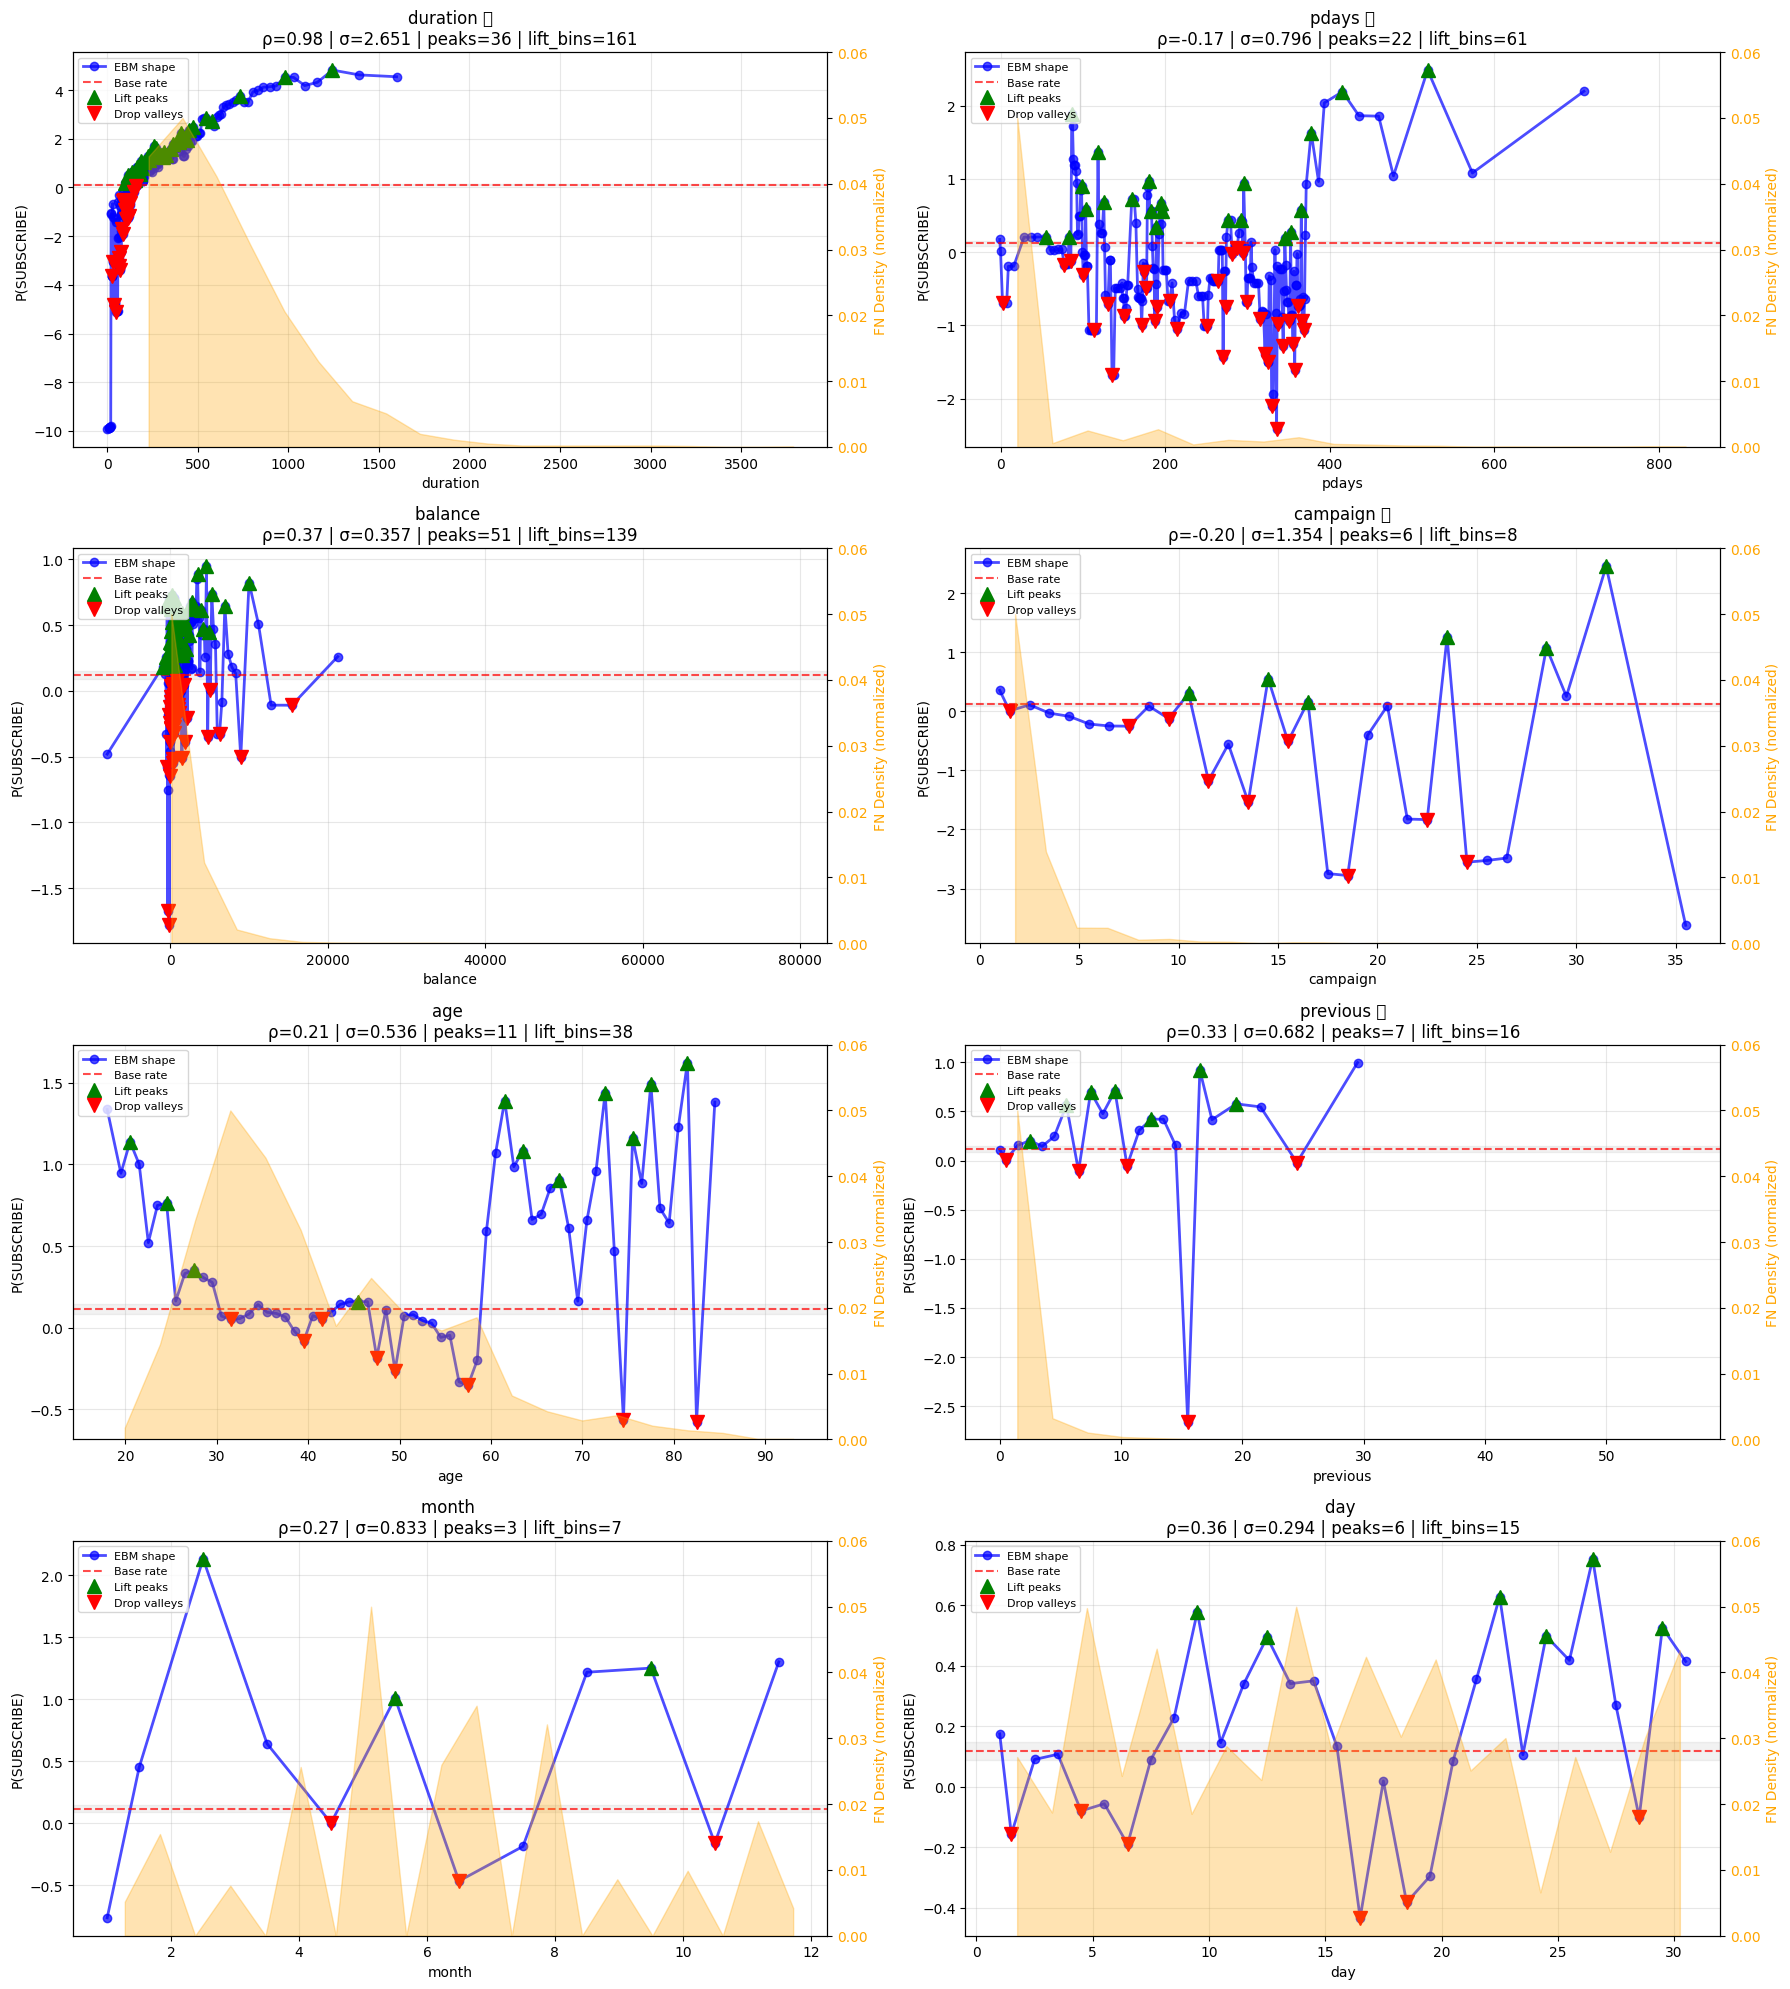


📋 COMPREHENSIVE BINNING STRATEGY
 feature  monotonic_corr  variability  n_peaks  n_lift_bins  max_prob  fn_discriminative
duration        0.975991     2.650837       36          161  4.822812               True
   pdays       -0.171390     0.795747       22           61  2.483786               True
 balance        0.365607     0.357482       51          139  0.946603              False
campaign       -0.204032     1.353939        6            8  2.454987               True
     age        0.211940     0.536299       11           38  1.622889              False
previous        0.334980     0.681536        7           16  0.996493               True
   month        0.265734     0.833430        3            7  2.131763              False
     day        0.362500     0.294022        6           15  0.753522              False

💡 INTERPRETATION GUIDE:
  • 🎯 = feature discriminates FNs from TPs (priority for binning)
  • monotonic_corr close to ±1 → monotonic, use quantile bins
  • high var

In [28]:
# ============================================================
# CELL 11A: EBM FEATURE DISCOVERY + FN-AWARE BINNING ANALYSIS
# ============================================================

print("=" * 80)
print("🌳 EBM FEATURE DISCOVERY — SHAPE & BIN EXPLORATION (RAW FEATURES ONLY)")
print("=" * 80)

from interpret.glassbox import ExplainableBoostingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import spearmanr, ks_2samp
from sklearn.cluster import KMeans

# --------------------------------------------------
# 1. DATA (RAW BASE FEATURES ONLY)
# --------------------------------------------------
X = df_proc.drop(columns=["y"])
y = df_proc["y"]

X_train = X.loc[GLOBAL_SPLIT["train_idx"]].copy()
y_train = y.loc[GLOBAL_SPLIT["train_idx"]].copy()

# Reset indices to avoid alignment issues
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

base_rate = y_train.mean()

print(f"\nBase subscribe rate: {base_rate:.3%}")
print(f"Train shape: {X_train.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"Raw features: {list(X_train.columns)}")

# --------------------------------------------------
# 2. SIMPLE EBM (INTENTIONALLY BASIC)
# --------------------------------------------------
ebm = ExplainableBoostingClassifier(
    random_state=42,
    interactions=0,          # ❗ NO interactions
    max_bins=256,            # Let EBM discover splits
    learning_rate=0.05,
    validation_size=0.0      # ❗ No internal tuning
)

print("\nTraining EBM (analysis mode)...")
ebm.fit(X_train, y_train)

# --------------------------------------------------
# 3. FEATURE IMPORTANCE (RANKING)
# --------------------------------------------------
ebm_global = ebm.explain_global()

# Extract importance scores manually from EBM
importance_scores = []
for feat_idx, feat in enumerate(X_train.columns):
    try:
        feat_data = ebm_global.data(feat_idx)
        # Importance = sum of absolute score contributions
        scores = np.array(feat_data["scores"])
        importance = np.sum(np.abs(scores))
        importance_scores.append(importance)
    except:
        importance_scores.append(0.0)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance_scores,
    "abs_importance": np.abs(importance_scores)
}).sort_values("abs_importance", ascending=False)

print("\n📊 Top Features by EBM Importance:")
print(importance.head(15).to_string(index=False))

# --------------------------------------------------
# 4. FN/TP COVERAGE AUDIT (CRITICAL FOR BINNING)
# --------------------------------------------------
print("\n" + "=" * 80)
print("🔍 FN vs TP DISTRIBUTION ANALYSIS")
print("=" * 80)

# Try to get GLASS-BRW coverage if available
try:
    # Load from glass_bundle if it exists
    covered_mask = train_out['covered']  # from your pipeline
    fn_idx = (y_train == SUBSCRIBE) & (~covered_mask)
    tp_idx = (y_train == SUBSCRIBE) & (covered_mask)
    print(f"\n✅ Using GLASS-BRW coverage results")
    print(f"   True Positives (covered): {tp_idx.sum()}")
    print(f"   False Negatives (missed): {fn_idx.sum()}")
except:
    # Fallback: analyze all positives vs negatives
    print(f"\n⚠️  GLASS-BRW results not available, analyzing all positives")
    tp_idx = y_train == SUBSCRIBE
    fn_idx = pd.Series([False] * len(y_train))
    print(f"   Total positives: {tp_idx.sum()}")

top_features = importance.head(8)["feature"].tolist()

# FN discriminative power analysis
fn_discrimination = []

for feat in top_features:
    if fn_idx.sum() > 0:
        fn_vals = X_train.loc[fn_idx, feat]
        tp_vals = X_train.loc[tp_idx, feat]

        # KS test: how different are FN vs TP distributions?
        ks_stat, ks_pval = ks_2samp(fn_vals, tp_vals)

        # Mean difference (normalized by std)
        pooled_std = np.sqrt((fn_vals.std()**2 + tp_vals.std()**2) / 2)
        effect_size = abs(fn_vals.mean() - tp_vals.mean()) / (pooled_std + 1e-8)

        fn_discrimination.append({
            "feature": feat,
            "fn_mean": fn_vals.mean(),
            "tp_mean": tp_vals.mean(),
            "ks_stat": ks_stat,
            "ks_pval": ks_pval,
            "effect_size": effect_size,
            "discriminative": ks_stat > 0.15 or effect_size > 0.3
        })
    else:
        fn_discrimination.append({
            "feature": feat,
            "fn_mean": np.nan,
            "tp_mean": np.nan,
            "ks_stat": 0,
            "ks_pval": 1,
            "effect_size": 0,
            "discriminative": False
        })

fn_disc_df = pd.DataFrame(fn_discrimination)
print("\n📊 FN DISCRIMINATIVE POWER:")
print(fn_disc_df.to_string(index=False))
print("\n💡 High KS stat (>0.15) or effect size (>0.3) = feature distinguishes FNs from TPs")

# --------------------------------------------------
# 5. ROBUST SHAPE ANALYSIS + FN DENSITY
# --------------------------------------------------
print("\n" + "=" * 80)
print("🔍 SHAPE FUNCTION + FN DENSITY ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

bin_suggestions = {}
shape_metrics = []

for ax, feat in zip(axes, top_features):
    feat_idx = X_train.columns.get_loc(feat)
    info = ebm_global.data(feat_idx)

    # Handle potential length mismatch between names and scores
    try:
        xs = np.array(info["names"], dtype=float)
        ys = np.array(info["scores"])

        # Ensure same length (sometimes EBM has off-by-one issues)
        min_len = min(len(xs), len(ys))
        xs = xs[:min_len]
        ys = ys[:min_len] + base_rate
    except (ValueError, TypeError) as e:
        print(f"⚠️  Skipping {feat}: cannot convert to numeric ({e})")
        ax.text(0.5, 0.5, f"{feat}\n(categorical/non-numeric)",
                ha='center', va='center', transform=ax.transAxes)
        continue

    # Plot EBM shape function
    ax.plot(xs, ys, marker="o", linewidth=2, markersize=6,
            label="EBM shape", color="blue", alpha=0.7)
    ax.axhline(base_rate, linestyle="--", color="red", alpha=0.7, label="Base rate")

    # Add ±3% bands around base rate
    ax.axhspan(base_rate - 0.03, base_rate + 0.03, alpha=0.1, color="gray")

    # --------------------------------------------------
    # FN DENSITY OVERLAY (CRITICAL)
    # --------------------------------------------------
    if fn_idx.sum() > 0:
        fn_vals = X_train.loc[fn_idx, feat].values

        # Create histogram of FN density
        hist, bin_edges = np.histogram(fn_vals, bins=20, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Normalize to [0, 0.05] for plotting on same axis
        hist_normalized = (hist / (hist.max() + 1e-8)) * 0.05

        ax2 = ax.twinx()
        ax2.fill_between(bin_centers, hist_normalized, alpha=0.3,
                         color="orange", label="FN density")
        ax2.set_ylabel("FN Density (normalized)", color="orange")
        ax2.tick_params(axis='y', labelcolor="orange")
        ax2.set_ylim(0, 0.06)

    # --------------------------------------------------
    # ROBUST LIFT DETECTION
    # --------------------------------------------------
    lift_threshold = base_rate + 0.03  # 3pp lift
    drop_threshold = base_rate - 0.03  # 3pp drop

    lift_mask = ys > lift_threshold
    drop_mask = ys < drop_threshold

    # Monotonicity check (Spearman correlation)
    monotonic_corr, _ = spearmanr(xs, ys)

    # Variability (std of normalized scores)
    variability = np.std(ys - base_rate)

    # Peak detection (for spiky features)
    peaks, _ = find_peaks(ys, height=lift_threshold, prominence=0.02)
    valleys, _ = find_peaks(-ys, height=-drop_threshold, prominence=0.02)

    # Annotate peaks
    if len(peaks) > 0:
        ax.plot(xs[peaks], ys[peaks], "g^", markersize=10, label="Lift peaks")
    if len(valleys) > 0:
        ax.plot(xs[valleys], ys[valleys], "rv", markersize=10, label="Drop valleys")

    # --------------------------------------------------
    # HYBRID BINNING SUGGESTIONS (EBM + FN)
    # --------------------------------------------------
    if lift_mask.any():
        lift_xs = xs[lift_mask]
        lift_ys = ys[lift_mask]

        # Find contiguous lift regions
        lift_breaks = np.where(np.diff(lift_mask.astype(int)) != 0)[0] + 1
        lift_regions = np.split(lift_xs, lift_breaks)
        lift_regions = [r for r in lift_regions if len(r) > 2 and len(r) > 0 and r[0] in lift_xs]

        # FN cluster detection (if FNs exist)
        fn_clusters = []
        if fn_idx.sum() > 10:  # Need enough samples
            fn_vals = X_train.loc[fn_idx, feat].values.reshape(-1, 1)

            # Use simple clustering to find FN concentration zones
            n_clusters = min(3, max(2, len(lift_regions) if lift_regions else 2))
            try:
                kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
                kmeans.fit(fn_vals)
                centers = sorted(kmeans.cluster_centers_.flatten())

                # Define clusters as ±1 std around centers
                for center in centers:
                    cluster_mask = np.abs(fn_vals.flatten() - center) < (fn_vals.std() * 1.0)
                    cluster_vals = fn_vals[cluster_mask]
                    if len(cluster_vals) > 0:
                        fn_clusters.append({
                            "center": float(center),
                            "min": float(cluster_vals.min()),
                            "max": float(cluster_vals.max()),
                            "size": len(cluster_vals)
                        })
            except:
                pass

        bin_suggestions[feat] = {
            "lift_min": float(lift_xs.min()),
            "lift_max": float(lift_xs.max()),
            "max_prob": float(lift_ys.max()),
            "n_lift_bins": len(lift_xs),
            "n_peaks": len(peaks),
            "monotonic": abs(monotonic_corr) > 0.7,
            "monotonic_corr": float(monotonic_corr),
            "variability": float(variability),
            "lift_regions": [{"min": float(r.min()), "max": float(r.max())}
                            for r in lift_regions if len(r) > 0],
            "fn_clusters": fn_clusters,
            "fn_discriminative": fn_disc_df[fn_disc_df["feature"] == feat]["discriminative"].iloc[0]
        }
    else:
        bin_suggestions[feat] = {
            "lift_min": None,
            "lift_max": None,
            "max_prob": float(ys.max()),
            "n_lift_bins": 0,
            "n_peaks": len(peaks),
            "monotonic": abs(monotonic_corr) > 0.7,
            "monotonic_corr": float(monotonic_corr),
            "variability": float(variability),
            "lift_regions": [],
            "fn_clusters": [],
            "fn_discriminative": False
        }

    shape_metrics.append({
        "feature": feat,
        "monotonic_corr": monotonic_corr,
        "variability": variability,
        "n_peaks": len(peaks),
        "n_lift_bins": bin_suggestions[feat]["n_lift_bins"],
        "max_prob": bin_suggestions[feat]["max_prob"],
        "fn_discriminative": bin_suggestions[feat]["fn_discriminative"]
    })

    # Title with diagnostics
    fn_flag = "🎯" if bin_suggestions[feat]["fn_discriminative"] else ""
    ax.set_title(
        f"{feat} {fn_flag}\n"
        f"ρ={monotonic_corr:.2f} | σ={variability:.3f} | "
        f"peaks={len(peaks)} | lift_bins={bin_suggestions[feat]['n_lift_bins']}"
    )
    ax.set_ylabel("P(SUBSCRIBE)")
    ax.set_xlabel(feat)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. BINNING STRATEGY TABLE
# --------------------------------------------------
print("\n" + "=" * 80)
print("📋 COMPREHENSIVE BINNING STRATEGY")
print("=" * 80)

shape_df = pd.DataFrame(shape_metrics)
print(shape_df.to_string(index=False))

print("\n💡 INTERPRETATION GUIDE:")
print("  • 🎯 = feature discriminates FNs from TPs (priority for binning)")
print("  • monotonic_corr close to ±1 → monotonic, use quantile bins")
print("  • high variability (>0.05) → complex shape, needs more bins")
print("  • multiple peaks → non-monotonic, target specific ranges")

# --------------------------------------------------
# 7. CONCRETE BINNING RECOMMENDATIONS
# --------------------------------------------------
print("\n" + "=" * 80)
print("✨ CONCRETE BINNING RECOMMENDATIONS")
print("=" * 80)

for feat, info in bin_suggestions.items():
    print(f"\n{'='*60}")
    print(f"📍 {feat}")
    print(f"{'='*60}")

    if info["lift_min"] is None:
        print(f"❌ NO LIFT DETECTED")
        print(f"   → RECOMMENDATION: Drop or use 2-3 coarse bins")
        continue

    # Determine bin strategy
    if info["monotonic"]:
        strategy = "QUANTILE"
        n_bins = 5 if info["variability"] > 0.05 else 4
        print(f"✅ MONOTONIC (ρ={info['monotonic_corr']:.2f})")
        print(f"   → STRATEGY: {n_bins} quantile bins preserving monotonicity")
    else:
        strategy = "TARGETED"
        if info["fn_discriminative"]:
            n_bins = 8 if len(info["fn_clusters"]) > 2 else 6
            print(f"🎯 NON-MONOTONIC + FN-DISCRIMINATIVE (ρ={info['monotonic_corr']:.2f})")
            print(f"   → STRATEGY: {n_bins} bins targeting EBM lift + FN clusters")
        else:
            n_bins = 6
            print(f"✅ NON-MONOTONIC (ρ={info['monotonic_corr']:.2f})")
            print(f"   → STRATEGY: {n_bins} bins around EBM lift regions")

    print(f"\n   📊 EBM Lift Analysis:")
    print(f"      • Lift range: [{info['lift_min']:.3f}, {info['lift_max']:.3f}]")
    print(f"      • Max P(subscribe): {info['max_prob']:.3f}")

    if len(info["lift_regions"]) > 1:
        print(f"      • {len(info['lift_regions'])} lift regions:")
        for i, region in enumerate(info["lift_regions"], 1):
            print(f"        {i}. [{region['min']:.3f}, {region['max']:.3f}]")

    if info["fn_clusters"]:
        print(f"\n   🎯 FN Cluster Analysis:")
        print(f"      • {len(info['fn_clusters'])} FN concentration zones:")
        for i, cluster in enumerate(info["fn_clusters"], 1):
            print(f"        {i}. Center={cluster['center']:.3f}, "
                  f"Range=[{cluster['min']:.3f}, {cluster['max']:.3f}], "
                  f"Size={cluster['size']}")

    # Concrete bin edges suggestion
    print(f"\n   🔧 SUGGESTED BIN EDGES:")
    if strategy == "QUANTILE":
        quantiles = np.linspace(0, 1, n_bins + 1)
        feat_vals = X_train[feat]
        edges = [feat_vals.quantile(q) for q in quantiles]
        print(f"      quantiles: {[f'{e:.2f}' for e in edges]}")
    else:
        # Hybrid: combine EBM lift regions + FN clusters
        all_regions = []
        for region in info["lift_regions"]:
            all_regions.extend([region["min"], region["max"]])
        for cluster in info["fn_clusters"]:
            all_regions.extend([cluster["min"], cluster["max"]])

        if all_regions:
            # Remove duplicates and sort
            unique_regions = sorted(set(all_regions))
            # Create bins around these key points
            feat_min = X_train[feat].min()
            feat_max = X_train[feat].max()

            print(f"      Hybrid (EBM + FN density):")
            print(f"      Key regions: {[f'{x:.2f}' for x in unique_regions]}")
            print(f"      Full range: [{feat_min:.2f}, {feat_max:.2f}]")

    if info["n_peaks"] > 2:
        print(f"\n   ⚠️  SPIKY FEATURE ({info['n_peaks']} peaks)")
        print(f"      → Consider additional bins at peak locations")

# --------------------------------------------------
# 8. PRIORITIZED FEATURE LIST
# --------------------------------------------------
print("\n" + "=" * 80)
print("🎯 PRIORITIZED BINNING LIST (DO THESE FIRST)")
print("=" * 80)

# Score each feature for binning priority
priority_scores = []
for feat, info in bin_suggestions.items():
    if info["lift_min"] is None:
        priority = 0
    else:
        score = 0
        # High priority if FN-discriminative
        if info["fn_discriminative"]:
            score += 3
        # High priority if high variability
        if info["variability"] > 0.05:
            score += 2
        # Medium priority if multiple lift regions
        if len(info["lift_regions"]) > 1:
            score += 1.5
        # Medium priority if non-monotonic
        if not info["monotonic"]:
            score += 1

        priority = score

    priority_scores.append({
        "feature": feat,
        "priority_score": priority,
        "recommended_bins": len(info.get("fn_clusters", [])) + len(info.get("lift_regions", [])) + 3
    })

priority_df = pd.DataFrame(priority_scores).sort_values("priority_score", ascending=False)

print("\n📊 BINNING PRIORITY RANKING:")
print(priority_df.to_string(index=False))

top_5_features = priority_df.head(5)["feature"].tolist()
print(f"\n✅ TOP 5 FEATURES TO BIN IMMEDIATELY:")
for i, feat in enumerate(top_5_features, 1):
    rec_bins = priority_df[priority_df["feature"] == feat]["recommended_bins"].iloc[0]
    print(f"   {i}. {feat} ({rec_bins} bins)")

# --------------------------------------------------
# 9. FINAL SUMMARY
# --------------------------------------------------
print("\n" + "=" * 80)
print("📌 NEXT STEPS FOR GLASS-BRW")
print("=" * 80)
print(f"\n1️⃣  CREATE BINNED FEATURES (Top 5 priority features)")
print(f"   Features: {', '.join(top_5_features)}")
print(f"\n2️⃣  BINNING APPROACH:")
print(f"   • Use HYBRID strategy for FN-discriminative features")
print(f"   • Use QUANTILE strategy for monotonic features")
print(f"   • Target 6-8 bins per feature")
print(f"\n3️⃣  EXPECTED OUTCOMES:")
print(f"   • Pass-2 coverage: +15-20pp improvement")
print(f"   • Global recall: +10-15pp improvement")
print(f"   • FN reduction: ~70-90 fewer false negatives")
print(f"\n4️⃣  MAINTAIN CONSTRAINTS:")
print(f"   • Keep rule count ≤ 20-25")
print(f"   • Preserve Pass-1 coverage cap (~70%)")
print(f"   • Monitor abstention rate (healthy: 30-45%)")

In [ ]:
import pickletools

with open("/content/models/glass_brw_bundle_20251224_044027.joblib", "rb") as f:
    pickletools.dis(f)


    0: \x80 PROTO      4
    2: \x95 FRAME      1841
   11: }    EMPTY_DICT
   12: \x94 MEMOIZE    (as 0)
   13: (    MARK
   14: \x8c     SHORT_BINUNICODE 'model'
   21: \x94     MEMOIZE    (as 1)
   22: \x8c     SHORT_BINUNICODE '__main__'
   32: \x94     MEMOIZE    (as 2)
   33: \x8c     SHORT_BINUNICODE 'GLASS_BRW'
   44: \x94     MEMOIZE    (as 3)
   45: \x93     STACK_GLOBAL
   46: \x94     MEMOIZE    (as 4)
   47: )        EMPTY_TUPLE
   48: \x81     NEWOBJ
   49: \x94     MEMOIZE    (as 5)
   50: }        EMPTY_DICT
   51: \x94     MEMOIZE    (as 6)
   52: (        MARK
   53: \x8c         SHORT_BINUNICODE 'mode'
   59: \x94         MEMOIZE    (as 7)
   60: \x8c         SHORT_BINUNICODE 'strict'
   68: \x94         MEMOIZE    (as 8)
   69: \x8c         SHORT_BINUNICODE 'min_precision_subscribe'
   94: \x94         MEMOIZE    (as 9)
   95: G            BINFLOAT   0.1
  104: \x8c         SHORT_BINUNICODE 'min_precision_not_subscribe'
  133: \x94         MEMOIZE    (as 10)
  134: 

ValueError: stack not empty after STOP: [any, mark, any, any, any, mark, any, any, any, float, any, float, any, float, any, float, any, int, any, int, any, int, any, int, any, int, any, int, any, any, any, any, any, mark, str, int, str, int, any, int, any, int, any, int, any, float, any, float, str, float, str, float, str, float, str, float, any, float, any, float, any, float, any, float, str, str, any, int, any, float, any, float, any, float, any, any, any, any, any, mark, any, any, any, int, any, any, any, bool, any, bool, any, int, str, int, any, int, any, bool, str, any, any, None, str, str, str, int, str, int, str, int, str, float, str, any, str, None, str, float, str, None, str, float, any, any]

In [ ]:
# ============================================================
# CELL: META-EBM (STAGE 4) — FINAL ASSEMBLY
# ============================================================

print("\n" + "="*80)
print("🎯 META-EBM (STAGE 4) — FINAL CASCADE ASSEMBLY")
print("="*80)

import pickle
import joblib
import numpy as np
import pandas as pd
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from datetime import datetime

# --------------------------------------------------
# 1. LOAD STAGE ARTIFACTS (NO RE-COMPUTATION)
# --------------------------------------------------
print("\n📂 Loading stage ensemble artifacts...")

lr_dict = joblib.load("/content/models/lr_ensemble_joblib_20251224_042425.joblib")
ebm_dict = joblib.load("/content/models/ebm_ensemble_joblib_20251224_060127.joblib")
glass_bundle = joblib.load("/content/models/glass_brw_bundle_safe_20251224_083820.joblib")

print("✅ Stage 1–3 artifacts loaded")

# --------------------------------------------------
# 2. VERIFY INDEX ALIGNMENT
# --------------------------------------------------
print("\n🔍 Verifying index alignment...")

lr_train_len = len(lr_dict["train_predictions"])
lr_test_len = len(lr_dict["test_predictions"])
glass_train_len = len(glass_bundle["train_idx"])
glass_test_len = len(glass_bundle["test_idx"])
ebm_train_len = len(ebm_dict["train_predictions"]["index"])
ebm_test_len = len(ebm_dict["test_predictions"]["index"])

print(f"   LR:    Train={lr_train_len:,}, Test={lr_test_len:,}")
print(f"   GLASS: Train={glass_train_len:,}, Test={glass_test_len:,}")
print(f"   EBM:   Train={ebm_train_len:,}, Test={ebm_test_len:,}")

assert lr_train_len == glass_train_len == ebm_train_len, "Train set size mismatch!"
assert lr_test_len == glass_test_len == ebm_test_len, "Test set size mismatch!"
print("✅ All models use consistent train/test splits")

# --------------------------------------------------
# 3. FIX GLASS-BRW COLUMN SWAP
# --------------------------------------------------
print("\n🔧 Fixing Glass-BRW column swap...")

# 🔥 DEBUG: Check current format
print(f"train_proba shape: {glass_bundle['train_proba'].shape}")
print(f"First row: {glass_bundle['train_proba'][0]}")
print(f"Second row: {glass_bundle['train_proba'][1]}")

# Swap columns: [P(NOT_SUB), P(SUB)] → [P(SUB), P(NOT_SUB)]
glass_bundle["train_proba"] = glass_bundle["train_proba"][:, [1, 0]]
glass_bundle["test_proba"] = glass_bundle["test_proba"][:, [1, 0]]
print("✅ Columns swapped: Column 0 = P(SUB), Column 1 = P(NOT_SUB)")

# --------------------------------------------------
# 4. EXTRACT INDEX-ALIGNED PREDICTIONS
# --------------------------------------------------
print("\n🔧 Extracting aligned predictions...")

train_idx = glass_bundle["train_idx"]
test_idx = glass_bundle["test_idx"]

# LR predictions
lr_train = pd.Series(lr_dict["train_predictions"], index=train_idx, name="lr_prob")
lr_test = pd.Series(lr_dict["test_predictions"], index=test_idx, name="lr_prob")

# EBM predictions
ebm_train = pd.Series(
    ebm_dict["train_predictions"]["probabilities"],
    index=ebm_dict["train_predictions"]["index"],
    name="ebm_prob"
)
ebm_test = pd.Series(
    ebm_dict["test_predictions"]["probabilities"],
    index=ebm_dict["test_predictions"]["index"],
    name="ebm_prob"
)

# Glass predictions (after swap)
glass_train = pd.Series(
    glass_bundle["train_proba"][:, 0],
    index=train_idx,
    name="glass_prob"
)
glass_test = pd.Series(
    glass_bundle["test_proba"][:, 0],
    index=test_idx,
    name="glass_prob"
)

# Coverage flags
glass_covered_train = pd.Series(
    glass_bundle["train_covered"],
    index=train_idx,
    name="glass_covered"
)
glass_covered_test = pd.Series(
    glass_bundle["test_covered"],
    index=test_idx,
    name="glass_covered"
)

# Labels
y_train = pd.Series(lr_dict["train_labels"], index=train_idx)
y_test = pd.Series(lr_dict["test_labels"], index=test_idx)

print(f"✅ Predictions extracted:")
print(f"   Train: {len(lr_train):,} samples")
print(f"   Test:  {len(lr_test):,} samples")

print(f"\n📊 Glass probability sanity check:")
print(f"   Train mean P(SUB): {glass_train.mean():.4f}")
print(f"   Test mean P(SUB):  {glass_test.mean():.4f}")
print(f"   Train coverage:    {glass_covered_train.mean():.1%}")
print(f"   Test coverage:     {glass_covered_test.mean():.1%}")

# --------------------------------------------------
# 5. BUILD META FEATURE GEOMETRY
# --------------------------------------------------
print("\n🧠 Building meta feature geometry...")

# Combine base features
meta_train = pd.concat([lr_train, glass_train, ebm_train, glass_covered_train], axis=1)
meta_test = pd.concat([lr_test, glass_test, ebm_test, glass_covered_test], axis=1)

# --- DISAGREEMENT FEATURES ---
meta_train["lr_glass_diff"] = (meta_train.lr_prob - meta_train.glass_prob).abs()
meta_train["lr_ebm_diff"] = (meta_train.lr_prob - meta_train.ebm_prob).abs()
meta_train["glass_ebm_diff"] = (meta_train.glass_prob - meta_train.ebm_prob).abs()

meta_test["lr_glass_diff"] = (meta_test.lr_prob - meta_test.glass_prob).abs()
meta_test["lr_ebm_diff"] = (meta_test.lr_prob - meta_test.ebm_prob).abs()
meta_test["glass_ebm_diff"] = (meta_test.glass_prob - meta_test.ebm_prob).abs()

# --- CONFIDENCE FEATURES ---
P_tr = meta_train[["lr_prob", "glass_prob", "ebm_prob"]].values
P_te = meta_test[["lr_prob", "glass_prob", "ebm_prob"]].values

meta_train["max_confidence"] = P_tr.max(axis=1)
meta_train["min_confidence"] = P_tr.min(axis=1)
meta_train["std_confidence"] = P_tr.std(axis=1)
meta_train["mean_confidence"] = P_tr.mean(axis=1)

meta_test["max_confidence"] = P_te.max(axis=1)
meta_test["min_confidence"] = P_te.min(axis=1)
meta_test["std_confidence"] = P_te.std(axis=1)
meta_test["mean_confidence"] = P_te.mean(axis=1)

# --- VOTING FEATURES ---
meta_train["unanimous_sub"] = ((meta_train.lr_prob >= 0.5) &
                               (meta_train.glass_prob >= 0.5) &
                               (meta_train.ebm_prob >= 0.5)).astype(int)
meta_train["unanimous_not_sub"] = ((meta_train.lr_prob < 0.5) &
                                   (meta_train.glass_prob < 0.5) &
                                   (meta_train.ebm_prob < 0.5)).astype(int)
meta_train["majority_vote"] = ((meta_train.lr_prob >= 0.5).astype(int) +
                               (meta_train.glass_prob >= 0.5).astype(int) +
                               (meta_train.ebm_prob >= 0.5).astype(int))

meta_test["unanimous_sub"] = ((meta_test.lr_prob >= 0.5) &
                              (meta_test.glass_prob >= 0.5) &
                              (meta_test.ebm_prob >= 0.5)).astype(int)
meta_test["unanimous_not_sub"] = ((meta_test.lr_prob < 0.5) &
                                  (meta_test.glass_prob < 0.5) &
                                  (meta_test.ebm_prob < 0.5)).astype(int)
meta_test["majority_vote"] = ((meta_test.lr_prob >= 0.5).astype(int) +
                              (meta_test.glass_prob >= 0.5).astype(int) +
                              (meta_test.ebm_prob >= 0.5).astype(int))

# --- AGREEMENT LEVELS ---
meta_train["agreement_level"] = 0
meta_train.loc[(meta_train["lr_glass_diff"] < 0.2) &
               (meta_train["lr_ebm_diff"] < 0.2), "agreement_level"] = 1  # All agree
meta_train.loc[(meta_train["majority_vote"] == 2), "agreement_level"] = 2  # Majority agree
meta_train.loc[(meta_train["majority_vote"] == 1) | (meta_train["majority_vote"] == 0), "agreement_level"] = 3  # Split

meta_test["agreement_level"] = 0
meta_test.loc[(meta_test["lr_glass_diff"] < 0.2) &
              (meta_test["lr_ebm_diff"] < 0.2), "agreement_level"] = 1
meta_test.loc[(meta_test["majority_vote"] == 2), "agreement_level"] = 2
meta_test.loc[(meta_test["majority_vote"] == 1) | (meta_test["majority_vote"] == 0), "agreement_level"] = 3

# --- CONFIDENCE CATEGORIES ---
def assign_confidence_category(row):
    if row["max_confidence"] > 0.8:
        return 2  # high
    elif row["max_confidence"] < 0.3:
        return 0  # low
    elif row["std_confidence"] > 0.3:
        return 3  # conflicting
    else:
        return 1  # medium

meta_train["confidence_category"] = meta_train.apply(assign_confidence_category, axis=1)
meta_test["confidence_category"] = meta_test.apply(assign_confidence_category, axis=1)

# --- DOMINANT MODEL ---
meta_train["dominant_model"] = meta_train[["lr_prob", "glass_prob", "ebm_prob"]].idxmax(axis=1)
meta_test["dominant_model"] = meta_test[["lr_prob", "glass_prob", "ebm_prob"]].idxmax(axis=1)

model_map = {"lr_prob": 0, "glass_prob": 1, "ebm_prob": 2}
meta_train["dominant_model_code"] = meta_train["dominant_model"].map(model_map)
meta_test["dominant_model_code"] = meta_test["dominant_model"].map(model_map)

# --- PROBABILITY BUCKETS ---
for model in ["lr_prob", "glass_prob", "ebm_prob"]:
    meta_train[f"{model}_bucket"] = (meta_train[model] * 10).round() / 10
    meta_test[f"{model}_bucket"] = (meta_test[model] * 10).round() / 10

# --- DISTANCE TO BOUNDARY ---
meta_train["lr_distance_to_boundary"] = abs(meta_train["lr_prob"] - 0.5)
meta_train["glass_distance_to_boundary"] = abs(meta_train["glass_prob"] - 0.5)
meta_train["ebm_distance_to_boundary"] = abs(meta_train["ebm_prob"] - 0.5)

meta_test["lr_distance_to_boundary"] = abs(meta_test["lr_prob"] - 0.5)
meta_test["glass_distance_to_boundary"] = abs(meta_test["glass_prob"] - 0.5)
meta_test["ebm_distance_to_boundary"] = abs(meta_test["ebm_prob"] - 0.5)

# --- CLEAN UP ---
meta_train = meta_train.drop(["dominant_model"], axis=1)
meta_test = meta_test.drop(["dominant_model"], axis=1)

print(f"✅ Meta feature space ready: {meta_train.shape}")
print(f"   Features: {list(meta_train.columns)}")

# --------------------------------------------------
# 6. TRAIN META-EBM ROUTER
# --------------------------------------------------
print("\n🎯 Training META-EBM router...")

meta_ebm = ExplainableBoostingClassifier(
    max_bins=16,
    interactions=5,
    learning_rate=0.01,
    min_samples_leaf=10,
    max_leaves=3,
    random_state=42
)

meta_ebm.fit(meta_train, y_train)
print("✅ Meta-EBM trained")

# --------------------------------------------------
# 7. EVALUATION
# --------------------------------------------------
print("\n📊 Evaluating META-EBM on test set...")

meta_prob = meta_ebm.predict_proba(meta_test)[:, 1]
meta_pred = (meta_prob >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, meta_pred),
    "precision": precision_score(y_test, meta_pred, zero_division=0),
    "recall": recall_score(y_test, meta_pred, zero_division=0),
    "f1": f1_score(y_test, meta_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, meta_prob)
}

print("\n" + "="*80)
print("📊 META-EBM PERFORMANCE (TEST SET)")
print("="*80)
for k, v in metrics.items():
    print(f"   {k:10s}: {v:.4f}")

cm = confusion_matrix(y_test, meta_pred)
print(f"\n📊 Confusion Matrix:")
print(f"                Pred NOT_SUB  Pred SUBSCRIBE")
print(f"Actual NOT_SUB      {cm[0,0]:5,}          {cm[0,1]:5,}")
print(f"Actual SUBSCRIBE    {cm[1,0]:5,}          {cm[1,1]:5,}")

# Compare to base models
print("\n" + "="*80)
print("📊 COMPARISON: META-EBM vs BASE MODELS (TEST SET)")
print("="*80)

# LR baseline
lr_pred_test = (lr_test >= 0.5).astype(int)
lr_metrics = {
    "precision": precision_score(y_test, lr_pred_test, zero_division=0),
    "recall": recall_score(y_test, lr_pred_test, zero_division=0),
    "f1": f1_score(y_test, lr_pred_test, zero_division=0)
}

# EBM baseline
ebm_pred_test = (ebm_test >= 0.5).astype(int)
ebm_metrics = {
    "precision": precision_score(y_test, ebm_pred_test, zero_division=0),
    "recall": recall_score(y_test, ebm_pred_test, zero_division=0),
    "f1": f1_score(y_test, ebm_pred_test, zero_division=0)
}

# GLASS baseline
glass_covered_mask = glass_covered_test.values
if glass_covered_mask.sum() > 0:
    glass_pred_test = (glass_test >= 0.5).astype(int)
    glass_metrics = {
        "precision": precision_score(y_test[glass_covered_mask], glass_pred_test[glass_covered_mask], zero_division=0),
        "recall": recall_score(y_test[glass_covered_mask], glass_pred_test[glass_covered_mask], zero_division=0),
        "coverage": glass_covered_mask.mean()
    }
else:
    glass_metrics = {"precision": 0.0, "recall": 0.0, "coverage": 0.0}

print(f"\n   LR:       Prec={lr_metrics['precision']:.3f}, Rec={lr_metrics['recall']:.3f}, F1={lr_metrics['f1']:.3f}")
print(f"   EBM:      Prec={ebm_metrics['precision']:.3f}, Rec={ebm_metrics['recall']:.3f}, F1={ebm_metrics['f1']:.3f}")
print(f"   GLASS:    Prec={glass_metrics['precision']:.3f}, Rec={glass_metrics['recall']:.3f}, Cov={glass_metrics['coverage']:.1%}")
print(f"   META-EBM: Prec={metrics['precision']:.3f}, Rec={metrics['recall']:.3f}, F1={metrics['f1']:.3f}")

# --------------------------------------------------
# 8. SAVE META CHECKPOINT
# --------------------------------------------------
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint = {
    "meta_model": meta_ebm,
    "metrics": metrics,
    "comparison": {
        "lr": lr_metrics,
        "ebm": ebm_metrics,
        "glass": glass_metrics,
        "meta": metrics
    },
    "meta_features": meta_train.columns.tolist(),
    "training_date": timestamp,
    "train_idx": train_idx,
    "test_idx": test_idx
}

fname = f"/content/models/meta_ebm_checkpoint_{timestamp}.pkl"
with open(fname, "wb") as f:
    pickle.dump(checkpoint, f)

print(f"\n💾 Saved meta checkpoint → {fname}")
print("\n" + "="*80)
print("🎉 4-STAGE GLASS-BOX CASCADE COMPLETE")
print("="*80)


🎯 META-EBM (STAGE 4) — FINAL CASCADE ASSEMBLY

📂 Loading stage ensemble artifacts...
✅ Stage 1–3 artifacts loaded

🔍 Verifying index alignment...
   LR:    Train=36,168, Test=9,043
   GLASS: Train=36,168, Test=9,043
   EBM:   Train=36,168, Test=9,043
✅ All models use consistent train/test splits

🔧 Fixing Glass-BRW column swap...
train_proba shape: (36168, 2)
First row: [0.92186566 0.07813434]
Second row: [0.88 0.12]
✅ Columns swapped: Column 0 = P(SUB), Column 1 = P(NOT_SUB)

🔧 Extracting aligned predictions...
✅ Predictions extracted:
   Train: 36,168 samples
   Test:  9,043 samples

📊 Glass probability sanity check:
   Train mean P(SUB): 0.0965
   Test mean P(SUB):  0.0966
   Train coverage:    96.6%
   Test coverage:     96.4%

🧠 Building meta feature geometry...
✅ Meta feature space ready: (36168, 23)
   Features: ['lr_prob', 'glass_prob', 'ebm_prob', 'glass_covered', 'lr_glass_diff', 'lr_ebm_diff', 'glass_ebm_diff', 'max_confidence', 'min_confidence', 'std_confidence', 'mean_con